In [1]:
!pip install -q "chronos-forecasting>=2.0.0" \
               "neuralforecast@git+https://github.com/Nixtla/neuralforecast.git" \
               "pandas[pyarrow]" \
               scikit-learn \
               fastdtw

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 11.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.4/287.4 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.5/849.5 kB 62.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.4/72.4 MB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 62.2 MB/s eta 0:00:00


In [2]:
import os
import pathlib
import requests

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from pandas.tseries.frequencies import to_offset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import torch
from chronos import Chronos2Pipeline

from neuralforecast import NeuralForecast
from neuralforecast.models import PatchTST, DLinear, TimeMixer, iTransformer

plt.rcParams["figure.dpi"] = 120

SEQ_LEN = 336            # input / window length for all models

# Simple train/val/test ratios (no leakage into test)
TRAIN_RATIO = 0.7
VAL_RATIO = 0.1  # test gets the remaining 0.2

DATA_DIR = pathlib.Path("./data")
DATA_DIR.mkdir(exist_ok=True, parents=True)

DATASETS = {
    "ETTh1":   DATA_DIR / "ETTh1.csv",
    "ETTm1":   DATA_DIR / "ETTm1.csv",
    "ETTm2":   DATA_DIR / "ETTm2.csv",
    "Weather": DATA_DIR / "weather.csv",
    "ESNet":   DATA_DIR / "r-nova-fd-01_metrics_patchtst_ffill.csv",
}

TARGET_COL = "OT"
TIME_COL = "date"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [3]:
BASE_URL = (
    "https://huggingface.co/datasets/"
    "pkr7098/time-series-forecasting-datasets/resolve/main"
)

FILES = {
    "ETTh1": "ETTh1.csv",
    "ETTm1": "ETTm1.csv",
    "ETTm2": "ETTm2.csv",
    "Weather": "weather.csv",
}

def download_file(name: str, filename: str, overwrite: bool = False):
    url = f"{BASE_URL}/{filename}"
    dest_path = DATA_DIR / filename

    if dest_path.exists() and not overwrite:
        print(f"[skip] {name}: {dest_path} already exists")
        return

    print(f"[download] {name} from {url}")
    resp = requests.get(url, stream=True)
    resp.raise_for_status()
    with open(dest_path, "wb") as f:
        for chunk in resp.iter_content(chunk_size=8192):
            if chunk:
                f.write(chunk)
    print(f"[ok] Saved to {dest_path}")

print(f"Saving datasets to: {DATA_DIR.resolve()}")
for name, fname in FILES.items():
    download_file(name, fname)
print("Done.")

Saving datasets to: /content/data
[download] ETTh1 from https://huggingface.co/datasets/pkr7098/time-series-forecasting-datasets/resolve/main/ETTh1.csv
[ok] Saved to data/ETTh1.csv
[download] ETTm1 from https://huggingface.co/datasets/pkr7098/time-series-forecasting-datasets/resolve/main/ETTm1.csv
[ok] Saved to data/ETTm1.csv
[download] ETTm2 from https://huggingface.co/datasets/pkr7098/time-series-forecasting-datasets/resolve/main/ETTm2.csv
[ok] Saved to data/ETTm2.csv
[download] Weather from https://huggingface.co/datasets/pkr7098/time-series-forecasting-datasets/resolve/main/weather.csv
[ok] Saved to data/weather.csv
Done.


In [4]:
pipeline = Chronos2Pipeline.from_pretrained(
    "amazon/chronos-2",
    device_map=device,
)

pipeline

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/478M [00:00<?, ?B/s]

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from pandas.tseries.frequencies import to_offset
from fastdtw import fastdtw

def compute_dtw_tdi(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float).ravel()
    y_pred = np.asarray(y_pred, dtype=float).ravel()
    assert y_true.shape == y_pred.shape

    dist, path = fastdtw(y_true, y_pred)
    shifts = [abs(i - j) for (i, j) in path]
    tdi = (np.mean(shifts) / len(y_true)) if shifts else 0.0
    return float(dist), float(tdi)


# ---------- PatchTST / LTSF-style splits ----------

def get_ltsf_splits(name: str):
    """
    Return (n_train, n_val, n_test) for each dataset, following the
    standard PatchTST / LTSF convention.

    ETTh1: hourly   -> 12/4/4 months   (30 days per month, 24 pts/day)
    ETTm1/2: 15-min -> 12/4/4 months   (30 days per month, 96 pts/day)
    Weather: canonical counts used in LTSF benchmarks
    """
    if name == "ETTh1":
        points_per_day = 24          # hourly
        days_per_month = 30
        n_train = 12 * days_per_month * points_per_day
        n_val   =  4 * days_per_month * points_per_day
        n_test  =  4 * days_per_month * points_per_day
        return n_train, n_val, n_test

    if name in ["ETTm1", "ETTm2"]:
        points_per_day = 24 * 4      # 15-min
        days_per_month = 30
        n_train = 12 * days_per_month * points_per_day
        n_val   =  4 * days_per_month * points_per_day
        n_test  =  4 * days_per_month * points_per_day
        return n_train, n_val, n_test

    if name == "Weather":
        # These are the standard counts used in PatchTST/LTSF code
        n_train = 36792
        n_val   =  5271
        n_test  = 10540
        return n_train, n_val, n_test

    raise ValueError(f"No LTSF-style split defined for dataset '{name}'.")


# ---------- Timestamp regularization ----------

def make_regular_timestamps(timestamps: pd.Series, series_id: str) -> pd.DatetimeIndex:
    """
    Ensure timestamps are on a regular grid so Chronos-2 and NF can infer freq.
    If pandas cannot infer a frequency, approximate it from the median delta.
    """
    ts = pd.to_datetime(timestamps).sort_values().reset_index(drop=True)

    freq = pd.infer_freq(ts)
    if freq is not None:
        return ts

    diffs = ts.diff().dropna()
    if diffs.empty:
        raise ValueError(f"Not enough timestamps for series {series_id} to infer a frequency.")

    median_delta = diffs.median()
    offset = to_offset(median_delta)

    print(f"[{series_id}] WARNING: irregular timestamps; using regular freq '{offset.freqstr}'")

    new_index = pd.date_range(start=ts.iloc[0], periods=len(ts), freq=offset)
    return new_index


# ---------- Dataset preparation (PatchTST-style splits, StdScaler on train only) ----------

def prepare_dataset(name: str, path: pathlib.Path):
    """
    Load CSV, fix timestamps, and split using:

      - ETTh1/ETTm1/ETTm2/Weather: standard PatchTST / LTSF-style splits
      - ESNet: custom split so that the first test horizon is *not* on the
        long, flat plateau, but on a high-variance window near the end.

    For all datasets:
    * StandardScaler is fit ONLY on the train region (first n_train points).
    * Context for models = train + val (0 .. test_start - 1).
    * Evaluation horizon = PREDICTION_LENGTH points starting at test_start.
    """
    if not path.exists():
        raise FileNotFoundError(f"Expected dataset at {path}")

    df = pd.read_csv(path)

    # ---------- ESNet special handling ----------
    if name == "ESNet":
      df = pd.read_csv(path)

      # Robust datetime parsing
      df[TIME_COL] = pd.to_datetime(df[TIME_COL], format="mixed", errors="coerce")
      df = df.dropna(subset=[TIME_COL]).sort_values(TIME_COL).reset_index(drop=True)

      octets_col = "ifHCOutOctets"
      if octets_col not in df.columns:
          raise KeyError(
              f"ESNet CSV must contain '{octets_col}' column "
              f"(available: {list(df.columns)})"
          )

      octets = df[octets_col].astype(float).to_numpy()
      ts     = df[TIME_COL].to_numpy()

      if len(octets) < 2:
          raise ValueError(f"{name}: not enough samples to compute bps.")

      # --- Compute bits per second (bps) from per-interval octet counts ---
      ts_ns = ts.astype("datetime64[ns]")
      dt = np.diff(ts_ns).astype("timedelta64[s]").astype(float)  # seconds

      BITS_PER_BYTE = 8.0
      bps = np.full_like(dt, np.nan, dtype=float)
      good = dt > 0
      bps[good] = octets[1:][good] * BITS_PER_BYTE / dt[good]

      # Fill NaNs
      rate_series = pd.Series(bps)
      rate_series = rate_series.interpolate(limit_direction="both")
      rate_series = rate_series.ffill().bfill()
      bps = rate_series.to_numpy(dtype=np.float32)

      # Align timestamps to bps (lose the first timestamp)
      ts_bps = ts[1:]

      # Regularize timestamps
      full_index = make_regular_timestamps(pd.Series(ts_bps), series_id=name)
      if len(full_index) != len(bps):
          raise ValueError(
              f"{name}: length mismatch between bps ({len(bps)}) and timestamps ({len(full_index)})"
          )

      # ------------------------------------------------------------
      # ESNet-only split: use last 15 days as horizon (timestamp-based)
      # ------------------------------------------------------------
      n = len(bps)
      if n < 10:
          raise ValueError(f"{name}: series too short (n={n}).")

      # Ensure full_index is a DatetimeIndex for time arithmetic
      if not isinstance(full_index, pd.DatetimeIndex):
          full_index = pd.DatetimeIndex(full_index)

      horizon_days = 15
      cutoff_ts = full_index[-1] - pd.Timedelta(days=horizon_days)

      # first index whose timestamp >= cutoff_ts
      test_start = int(np.searchsorted(full_index.values, cutoff_ts.to_datetime64(), side="left"))
      test_start = max(1, min(test_start, n - 1))  # keep valid

      pred_len = n - test_start  # ESNet horizon length in points

      # Train/val are everything before test_start
      train_ratio = 0.8
      n_train = int(train_ratio * test_start)
      n_train = max(1, n_train)
      n_val   = test_start - n_train
      n_test  = n - test_start

      print(
          f"[ESNet] n={n}, horizon_days={horizon_days}, pred_len={pred_len}, "
          f"n_train={n_train}, n_val={n_val}, n_test={n_test}, "
          f"test_start_idx={test_start}, test_start_ts={full_index[test_start]}"
      )

      # --- StandardScaler fit ONLY on train slice ---
      scaler = StandardScaler()
      scaler.fit(bps[:n_train].reshape(-1, 1))
      y_scaled = scaler.transform(bps.reshape(-1, 1)).flatten()

      # Context is ALL data before test_start
      context_scaled = y_scaled[:test_start]
      context_index  = full_index[:test_start]

      # Horizon is LAST 15 DAYS (in points)
      gt_scaled    = y_scaled[test_start:]
      future_index = full_index[test_start:]

      # Frequency inference
      freq = pd.infer_freq(full_index)
      if freq is None:
          diffs = pd.Series(full_index).diff().dropna()
          median_delta = diffs.median()
          freq = to_offset(median_delta).freqstr

      return {
          "name":           name,
          "y":              bps,
          "y_scaled":       y_scaled,
          "scaler":         scaler,
          "full_index":     full_index,
          "context_scaled": context_scaled,
          "gt_scaled":      gt_scaled,
          "context_index":  context_index,
          "future_index":   future_index,
          "freq":           freq,
          "n_train":        n_train,
          "n_val":          n_val,
          "n_test":         n_test,
          "train_end":      n_train,
          "val_end":        n_train + n_val,
          "test_start":     test_start,
          "test_end":       n,
          "pred_len":       pred_len,   # IMPORTANT: dataset-specific horizon length
          "horizon_days":   horizon_days,
      }

    # ---------- Default ETT/Weather path (unchanged) ----------
    df[TIME_COL] = pd.to_datetime(df[TIME_COL])
    df = df.sort_values(TIME_COL).reset_index(drop=True)

    full_index = make_regular_timestamps(df[TIME_COL], series_id=name)

    # Original OT target
    y = df[TARGET_COL].values.astype(np.float32)
    if len(y) != len(full_index):
        raise ValueError(f"{name}: length mismatch between values and timestamps.")

    # LTSF / PatchTST canonical splits
    n_train, n_val, n_test = get_ltsf_splits(name)
    needed = n_train + n_val + n_test
    n = len(y)

    if n < needed:
        raise ValueError(
            f"{name}: dataset length {n} is smaller than required "
            f"LTSF total {needed} (train={n_train}, val={n_val}, test={n_test})."
        )
    if n > needed:
        print(
            f"[{name}] INFO: dataset length {n} > LTSF total {needed}. "
            f"Using first {needed} points and ignoring extra tail."
        )

    # Truncate to canonical region
    y = y[:needed]
    full_index = full_index[:needed]
    n = needed

    # Define split borders
    train_end  = n_train              # [0, train_end)
    val_end    = n_train + n_val      # [train_end, val_end)
    test_start = val_end              # [test_start, test_end)
    test_end   = val_end + n_test     # == n

    if n_test < PREDICTION_LENGTH:
        raise ValueError(
            f"{name}: test length {n_test} is smaller than "
            f"prediction_length={PREDICTION_LENGTH}"
        )

    # --- StandardScaler fit ONLY on train slice (PatchTST style) ---
    scaler = StandardScaler()
    scaler.fit(y[:train_end].reshape(-1, 1))
    y_scaled = scaler.transform(y.reshape(-1, 1)).flatten()

    # Context: train + val (no leakage into test)
    context_scaled = y_scaled[:test_start]
    context_index  = full_index[:test_start]

    # Test horizon for evaluation: first PREDICTION_LENGTH points of canonical test
    gt_scaled    = y_scaled[test_start : test_start + PREDICTION_LENGTH]
    future_index = full_index[test_start : test_start + PREDICTION_LENGTH]

    # Frequency for NF / plotting
    freq = pd.infer_freq(full_index)
    if freq is None:
        diffs = pd.Series(full_index).diff().dropna()
        median_delta = diffs.median()
        freq = to_offset(median_delta).freqstr

    return {
        "name":         name,
        "y":            y,
        "y_scaled":     y_scaled,
        "scaler":       scaler,
        "full_index":   full_index,
        "context_scaled": context_scaled,
        "gt_scaled":      gt_scaled,
        "context_index":  context_index,
        "future_index":   future_index,
        "freq":         freq,
        "n_train":      n_train,
        "n_val":        n_val,
        "n_test":       n_test,
        "train_end":    train_end,
        "val_end":      val_end,
        "test_start":   test_start,
        "test_end":     test_end,
    }



# ---------- Chronos quantile column picker ----------

def pick_quantile_columns(ts_pred: pd.DataFrame):
    """
    For Chronos-2 predict_df() output, figure out lower/median/upper columns.
    Handles different naming patterns: '0.1', '0.5', '0.9', 'median', 'predictions', etc.
    """
    cols = list(ts_pred.columns)

    median_candidates = [c for c in cols if c in ("0.5", "median", "predictions", "mean")]
    lower_candidates  = [c for c in cols if c in ("0.1", "p10", "lower")]
    upper_candidates  = [c for c in cols if c in ("0.9", "p90", "upper")]

    if not median_candidates:
        median_candidates = [cols[0]]
    if not lower_candidates:
        lower_candidates = [cols[0]]
    if not upper_candidates:
        upper_candidates = [cols[-1]]

    median_col = median_candidates[0]
    lower_col  = lower_candidates[0]
    upper_col  = upper_candidates[0]

    print(f"Using columns for quantiles -> lower: {lower_col}, median: {median_col}, upper: {upper_col}")
    return lower_col, median_col, upper_col

# ---------- Plotting + metrics (unscaled + scaled) ----------
def plot_and_metrics(dataset, model_name, pred_scaled,
                     lower_scaled=None, upper_scaled=None,
                     results_dir=None):
    """
    Plot a single-horizon forecast and compute metrics.

    - ESNet: horizon = dataset['pred_len'] (last 15 days), plot only a short context window
             (default 15 days) immediately before test_start.
             Use log y-axis and set y-lims so history is not cut off (lower bound uses absolute
             minimum positive value in the displayed history+GT window).
    - Other datasets: context = last SEQ_LEN points before test_start; horizon = global PREDICTION_LENGTH.

    Plotting is done in original units. Metrics are computed in scaled space (MSE/MAE/DTW/TDI),
    ignoring NaNs in either gt or pred.
    """
    def _first_value(x):
        if hasattr(x, "iloc"):
            return x.iloc[0]
        return x[0]

    name       = dataset["name"]
    y_scaled   = dataset["y_scaled"]
    full_index = dataset["full_index"]
    scaler     = dataset["scaler"]
    test_start = int(dataset["test_start"])

    # Ensure Index
    if not isinstance(full_index, pd.Index):
        full_index = pd.Index(full_index)

    # ------------------------------------------------------------
    # Decide horizon length
    # ------------------------------------------------------------
    if name == "ESNet":
        horizon_len = int(dataset.get("pred_len", len(y_scaled) - test_start))
    else:
        horizon_len = int(PREDICTION_LENGTH)

    # ------------------------------------------------------------
    # Build context + horizon in SCALED space
    # ------------------------------------------------------------
    if name == "ESNet":
        # Plot only a short context window right before the horizon
        context_days = int(dataset.get("context_days", 15))
        horizon_days = int(dataset.get("horizon_days", 15))
        steps_per_day = int(np.round(horizon_len / max(horizon_days, 1)))
        context_len = int(context_days * steps_per_day)

        context_start = max(0, test_start - context_len)
        ctx_scaled = y_scaled[context_start:test_start]
        ctx_index  = full_index[context_start:test_start]

        gt_scaled  = y_scaled[test_start:test_start + horizon_len]
        hor_index  = full_index[test_start:test_start + horizon_len]
    else:
        context_start = max(0, test_start - SEQ_LEN)
        ctx_scaled = y_scaled[context_start:test_start]
        ctx_index  = full_index[context_start:test_start]

        gt_scaled  = y_scaled[test_start:test_start + horizon_len]
        hor_index  = full_index[test_start:test_start + horizon_len]

    # ------------------------------------------------------------
    # Sanitize predictions (scaled)
    # ------------------------------------------------------------
    pred_scaled = np.asarray(pred_scaled, dtype=float).ravel()
    gt_scaled_arr = np.asarray(gt_scaled, dtype=float).ravel()

    if pred_scaled.shape[0] < gt_scaled_arr.shape[0]:
        raise ValueError(
            f"{name} – {model_name}: prediction has length {pred_scaled.shape[0]} "
            f"but horizon length is {gt_scaled_arr.shape[0]}"
        )
    pred_scaled = pred_scaled[:gt_scaled_arr.shape[0]]

    # Optional intervals (scaled)
    if lower_scaled is not None and upper_scaled is not None:
        lower_scaled = np.asarray(lower_scaled, dtype=float).ravel()[:gt_scaled_arr.shape[0]]
        upper_scaled = np.asarray(upper_scaled, dtype=float).ravel()[:gt_scaled_arr.shape[0]]
    else:
        lower_scaled = upper_scaled = None

    # ------------------------------------------------------------
    # Convert to original units for plotting
    # ------------------------------------------------------------
    ctx_unscaled  = scaler.inverse_transform(np.asarray(ctx_scaled).reshape(-1, 1)).ravel()
    gt_unscaled   = scaler.inverse_transform(gt_scaled_arr.reshape(-1, 1)).ravel()
    pred_unscaled = scaler.inverse_transform(np.asarray(pred_scaled).reshape(-1, 1)).ravel()

    lower_unscaled = upper_unscaled = None
    if lower_scaled is not None and upper_scaled is not None:
        lower_unscaled = scaler.inverse_transform(lower_scaled.reshape(-1, 1)).ravel()
        upper_unscaled = scaler.inverse_transform(upper_scaled.reshape(-1, 1)).ravel()

    # ------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 4))

    ax.plot(ctx_index, ctx_unscaled, label="History", linewidth=1.0)
    ax.plot(hor_index, gt_unscaled, label="Ground truth", linewidth=1.5)
    ax.plot(hor_index, pred_unscaled, label=f"{model_name} forecast", linewidth=1.2)

    if lower_unscaled is not None and upper_unscaled is not None:
        ax.fill_between(
            hor_index, lower_unscaled, upper_unscaled,
            alpha=0.2, label="10–90% interval"
        )

    # Titles / labels
    if name == "ESNet" and "horizon_days" in dataset:
        ax.set_title(
            f"{name} – {model_name} – Horizon: last {dataset['horizon_days']} days ({len(gt_scaled_arr)} steps)"
        )
        ax.set_ylabel("Bandwidth(bits per second)")
    else:
        ax.set_title(f"{name} – {model_name} – Horizon {horizon_len}")
        ax.set_ylabel("Target (original units)")

    ax.set_xlabel("Time")

    # Datetime formatting (robust)
    if len(hor_index) > 0:
        first_x = _first_value(hor_index)
        if isinstance(first_x, (pd.Timestamp, np.datetime64)):
            ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d %H:%M"))
            fig.autofmt_xdate()

    # ------------------------------------------------------------
    # ESNet: force log scale + y-lims using absolute minimum in displayed data
    # ------------------------------------------------------------
    if name == "ESNet":
        ax.set_yscale("log")

        def _pos_finite(a):
            if a is None:
                return np.array([], dtype=float)
            a = np.asarray(a, dtype=float).ravel()
            return a[np.isfinite(a) & (a > 0)]

        # Lower bound: absolute minimum positive value in the displayed series (history + GT)
        displayed_series_pos = np.concatenate([_pos_finite(ctx_unscaled), _pos_finite(gt_unscaled)])
        if displayed_series_pos.size > 0:
            y_min = float(np.min(displayed_series_pos))
        else:
            # Shouldn't happen for bandwidth, but keep log safe
            y_min = 1e-12

        # Upper bound: max of anything that might appear in the horizon (GT + pred + intervals)
        top_pool = np.concatenate([
            _pos_finite(gt_unscaled),
            _pos_finite(pred_unscaled),
            _pos_finite(lower_unscaled),
            _pos_finite(upper_unscaled),
        ])
        if top_pool.size > 0:
            y_max = float(np.max(top_pool))
        else:
            y_max = max(y_min * 10.0, 1.0)

        # Light padding; keep bottom strictly positive
        bottom = max(y_min, 1e-12)
        top = max(y_max * 1.2, bottom * 10.0)

        ax.set_ylim(bottom=bottom, top=top)

    ax.legend(loc="best")

    fig_path = None
    if results_dir is not None:
        os.makedirs(results_dir, exist_ok=True)
        fig_path = os.path.join(results_dir, f"{name}_{model_name}_h{horizon_len}.png")
        fig.savefig(fig_path, bbox_inches="tight")

    plt.show()
    plt.close(fig)

    # ------------------------------------------------------------
    # Metrics (scaled space), NaN-robust
    # ------------------------------------------------------------
    pred_scaled_arr = np.asarray(pred_scaled, dtype=float).ravel()
    mask = np.isfinite(gt_scaled_arr) & np.isfinite(pred_scaled_arr)
    if not np.any(mask):
        raise ValueError(f"{name} – {model_name}: no finite values for metrics")

    gt_for_metrics   = gt_scaled_arr[mask]
    pred_for_metrics = pred_scaled_arr[mask]

    mse_scaled = mean_squared_error(gt_for_metrics, pred_for_metrics)
    mae_scaled = mean_absolute_error(gt_for_metrics, pred_for_metrics)
    dtw_scaled, tdi_scaled = compute_dtw_tdi(gt_for_metrics, pred_for_metrics)

    print(f"[{name}] {model_name} – single horizon (ALL METRICS SCALED)")
    print(f"MSE (scaled): {mse_scaled:.6f}")
    print(f"MAE (scaled): {mae_scaled:.6f}")
    print(f"DTW (scaled): {dtw_scaled:.6f}")
    print(f"TDI (scaled): {tdi_scaled:.6f}")

    return {
        "dataset":     name,
        "model":       model_name,
        "horizon_len": int(len(gt_scaled_arr)),
        "mse_scaled":  mse_scaled,
        "mae_scaled":  mae_scaled,
        "dtw_scaled":  dtw_scaled,
        "tdi_scaled":  tdi_scaled,
        "protocol":    "single_horizon_scaled",
        "fig_path":    fig_path,
    }

In [16]:
def chronos_predict_scaled(dataset, pipeline):
    """
    Run Chronos-2 on UNscaled data.

    - Non-ESNet:
        Context: last SEQ_LEN points before test_start (unscaled)
        Horizon: PREDICTION_LENGTH points starting at test_start
    - ESNet:
        Context: ALL points before test_start (unscaled)
        Horizon: dataset['pred_len'] points (last 15 days, timestamp-based)

    Returns predictions in *scaled* space so plot_and_metrics can treat
    Chronos outputs exactly like NF models.
    """
    name        = dataset["name"]
    y_unscaled  = np.asarray(dataset["y"], dtype=float).ravel()
    full_index  = dataset["full_index"]
    scaler      = dataset["scaler"]
    test_start  = int(dataset["test_start"])

    # Make sure full_index behaves like an Index
    if not isinstance(full_index, pd.Index):
        full_index = pd.Index(full_index)

    # Decide horizon length
    if name == "ESNet":
        horizon_len = int(dataset.get("pred_len", len(y_unscaled) - test_start))
    else:
        horizon_len = int(PREDICTION_LENGTH)

    # Build context (unscaled)
    if name == "ESNet":
        ctx_start = 0
    else:
        ctx_start = max(0, test_start - SEQ_LEN)

    ctx_end   = test_start
    ctx_vals  = y_unscaled[ctx_start:ctx_end]
    ctx_index = full_index[ctx_start:ctx_end]

    # Chronos expects a dataframe with id/timestamp/target (matches your notebook)
    context_df = pd.DataFrame(
        {
            "id":        name,
            "timestamp": ctx_index,
            "target":    ctx_vals,
        }
    )

    # IMPORTANT: predict_df expects df as the first positional argument
    pred_df = pipeline.predict_df(
        context_df,
        prediction_length=int(horizon_len),
        quantile_levels=[0.1, 0.5, 0.9],
        id_column="id",
        timestamp_column="timestamp",
        target="target",
    )

    ts_pred = pred_df.set_index("timestamp").sort_index()
    lower_col, median_col, upper_col = pick_quantile_columns(ts_pred)

    # Extract horizon in UNscaled units
    pred_unscaled  = ts_pred[median_col].to_numpy(dtype=np.float32)[:horizon_len]
    lower_unscaled = ts_pred[lower_col].to_numpy(dtype=np.float32)[:horizon_len]
    upper_unscaled = ts_pred[upper_col].to_numpy(dtype=np.float32)[:horizon_len]

    # Map Chronos outputs into the SAME StandardScaler space as NF models
    pred_scaled  = scaler.transform(pred_unscaled.reshape(-1, 1)).flatten()
    lower_scaled = scaler.transform(lower_unscaled.reshape(-1, 1)).flatten()
    upper_scaled = scaler.transform(upper_unscaled.reshape(-1, 1)).flatten()

    return pred_scaled, lower_scaled, upper_scaled

In [17]:
def nf_predict_scaled(dataset):
    """
    Train NeuralForecast models on UNscaled targets (original units),
    disable NF's internal scaling (scaler_type="identity"),
    then map forecasts into the shared StandardScaler space so that
    metrics are computed on standardized values.

    Returns: dict {model_name: pred_scaled (1D numpy array)}
    """
    name       = dataset["name"]
    y_unscaled = np.asarray(dataset["y"], dtype=float).ravel()
    full_index = dataset["full_index"]
    freq       = dataset["freq"]
    scaler     = dataset["scaler"]
    test_start = int(dataset["test_start"])

    # Horizon length: ESNet uses its custom pred_len, others use global PREDICTION_LENGTH
    if name == "ESNet":
        horizon_len = int(dataset.get("pred_len", len(y_unscaled) - test_start))
    else:
        horizon_len = int(PREDICTION_LENGTH)

    # Train on train+val only (up to test_start). This matches your original intent.
    train_df = pd.DataFrame(
        {
            "unique_id": name,
            "ds": full_index[:test_start],
            "y":  y_unscaled[:test_start],
        }
    )

    # NF models (match original behavior: identity scaler, stable training defaults)
    models = [
        DLinear(
            h=horizon_len,
            input_size=SEQ_LEN,
            n_series=1,
            scaler_type="identity",
            max_steps=1000,
            early_stop_patience_steps=3,
        ),
        PatchTST(
            h=horizon_len,
            input_size=SEQ_LEN,
            n_series=1,
            scaler_type="identity",
            max_steps=1000,
            early_stop_patience_steps=3,
        ),
        TimeMixer(
            h=horizon_len,
            input_size=SEQ_LEN,
            n_series=1,
            scaler_type="identity",
            max_steps=1000,
            early_stop_patience_steps=3,
        ),
        iTransformer(
            h=horizon_len,
            input_size=SEQ_LEN,
            n_series=1,
            scaler_type="identity",
            max_steps=1000,
            early_stop_patience_steps=3,
        ),
    ]

    # If you still want iTransformer skipped only for ESNet, keep this
    if name == "ESNet":
        models = [m for m in models if type(m).__name__ != "iTransformer"]

    nf = NeuralForecast(models=models, freq=freq)

    # Fit. If your installed NF version supports val_size, this helps stability.
    # Use a reasonable val_size without leaking into the horizon.
    try:
        # A conservative choice: 1/3 of train_df, but at least horizon_len (bounded)
        val_size = max(horizon_len, min(len(train_df) // 3, len(train_df) - horizon_len))
        nf.fit(df=train_df, val_size=val_size)
    except TypeError:
        # Older/newer NF versions may not accept val_size
        nf.fit(df=train_df)

    # Predict the next horizon_len steps after the end of train_df
    yhat_df = nf.predict().sort_values("ds")

    preds = {}
    for model in models:
        mname = type(model).__name__

        # Column naming can vary; prefer exact model name, else pick first non-id/ds column
        if mname in yhat_df.columns:
            col = mname
        else:
            value_cols = [c for c in yhat_df.columns if c not in ["unique_id", "ds"]]
            if not value_cols:
                raise ValueError(f"{name}: could not find prediction column in NF output")
            col = value_cols[0]

        # NF output is UNscaled (because scaler_type="identity" and y was unscaled)
        pred_unscaled = yhat_df[col].to_numpy(dtype=float).ravel()[:horizon_len]

        # Guard against NaNs (you hit this earlier with ESNet/iTransformer)
        if np.any(~np.isfinite(pred_unscaled)):
            s = pd.Series(pred_unscaled)
            pred_unscaled = s.interpolate(limit_direction="both").to_numpy(dtype=float)

        # Map into your shared StandardScaler space for metrics + plot_and_metrics
        pred_scaled = scaler.transform(pred_unscaled.reshape(-1, 1)).ravel()
        preds[mname] = pred_scaled

    return preds

In [18]:
BASE_RESULTS_DIR = "results"

Saving results to: results/h96

Dataset: ETTh1
[ETTh1] INFO: dataset length 17420 > LTSF total 14400. Using first 14400 points and ignoring extra tail.
Using columns for quantiles -> lower: 0.1, median: predictions, upper: 0.9


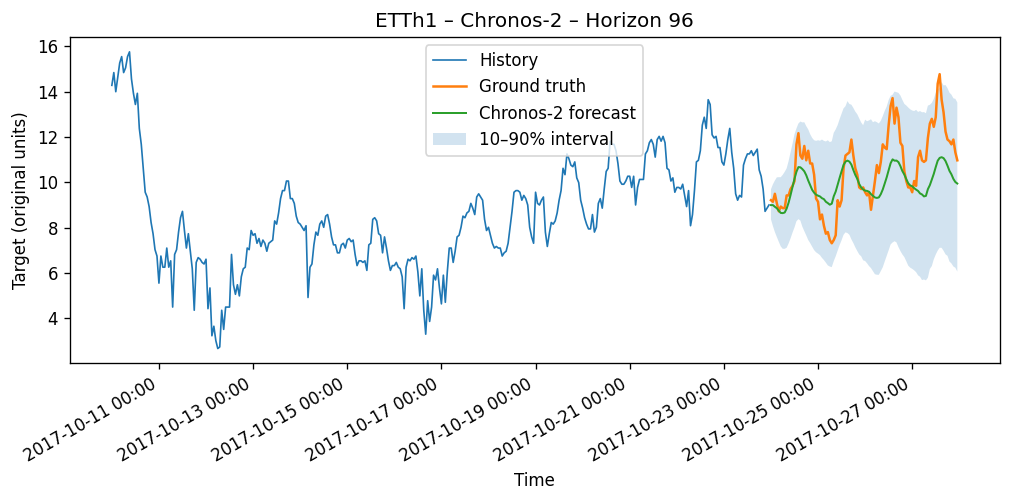

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


[ETTh1] Chronos-2 – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.021393
MAE (scaled): 0.114201
DTW (scaled): 9.930030
TDI (scaled): 0.164855


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train  │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler        │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ decomp        │ SeriesDecomp  │      0 │ train │     0 │
│ 4 │ linear_trend  │ Linear        │ 32.4 K │ train │     0 │
│ 5 │ linear_season │ Linear        │ 32.4 K │ train │     0 │
└───┴───────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 64.7 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 64.7 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

Output()

INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.rich_model_summary.RichModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.rich_model_summary.RichModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

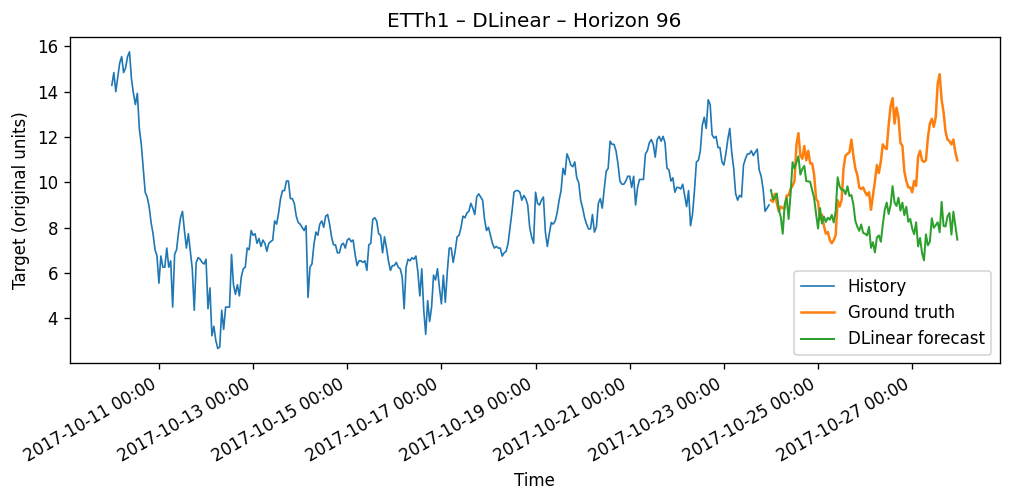

[ETTh1] DLinear – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.084096
MAE (scaled): 0.235436
DTW (scaled): 19.353409
TDI (scaled): 0.031417


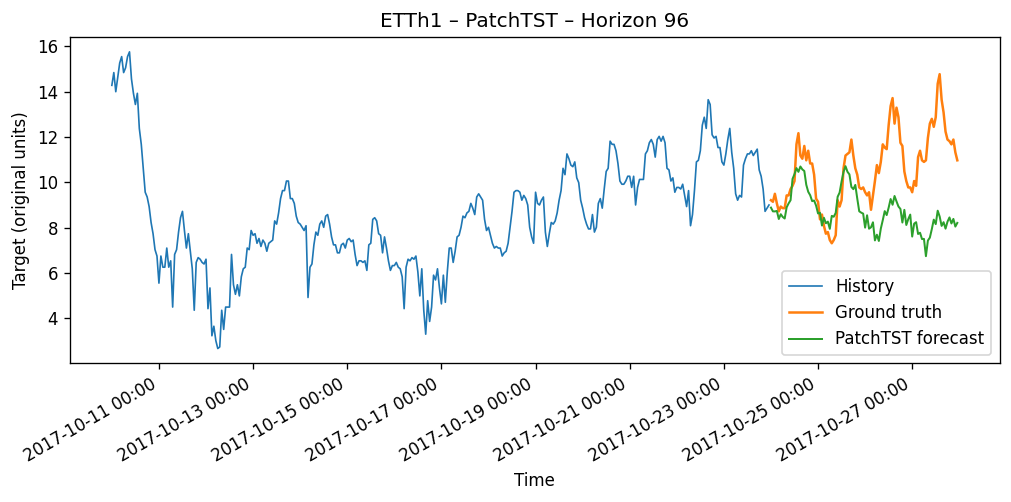

[ETTh1] PatchTST – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.077577
MAE (scaled): 0.218705
DTW (scaled): 18.591637
TDI (scaled): 0.022146


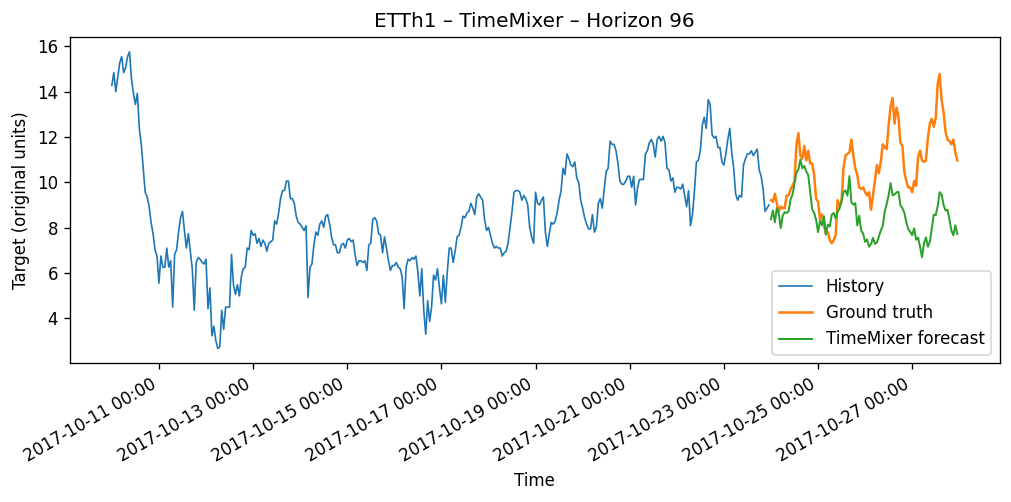

[ETTh1] TimeMixer – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.076842
MAE (scaled): 0.228453
DTW (scaled): 18.715198
TDI (scaled): 0.027462


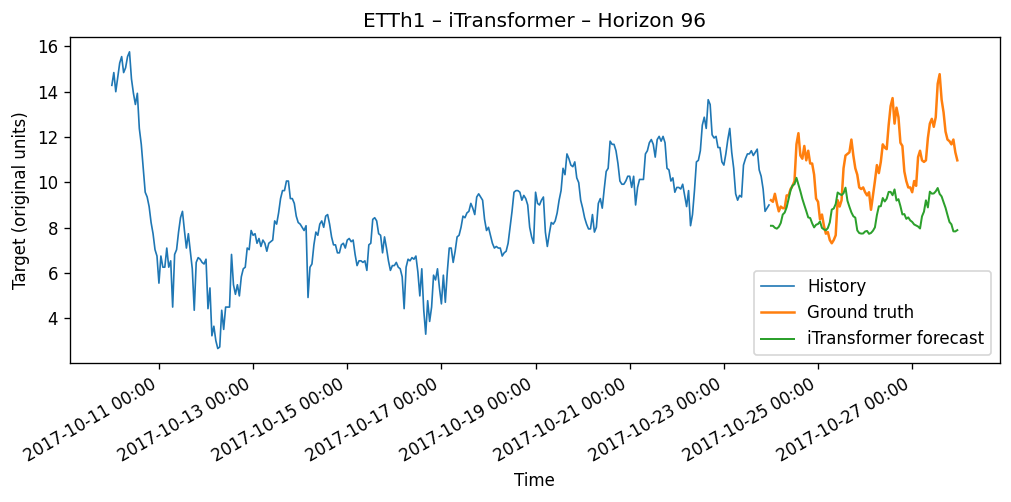

[ETTh1] iTransformer – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.065914
MAE (scaled): 0.221145
DTW (scaled): 15.971849
TDI (scaled): 0.128353

Dataset: ETTm1
[ETTm1] INFO: dataset length 69680 > LTSF total 57600. Using first 57600 points and ignoring extra tail.
Using columns for quantiles -> lower: 0.1, median: predictions, upper: 0.9


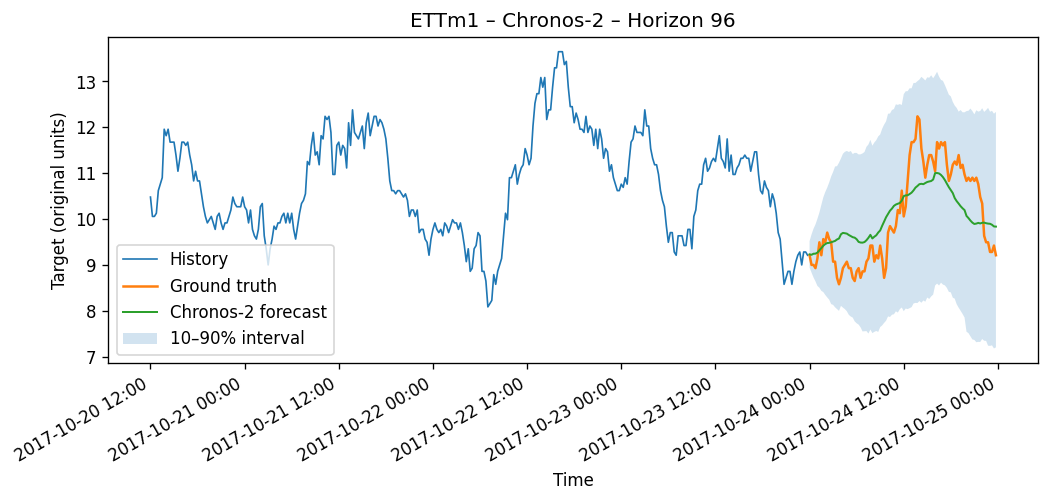

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


[ETTm1] Chronos-2 – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.005150
MAE (scaled): 0.062643
DTW (scaled): 4.032826
TDI (scaled): 0.115411


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train  │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler        │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ decomp        │ SeriesDecomp  │      0 │ train │     0 │
│ 4 │ linear_trend  │ Linear        │ 32.4 K │ train │     0 │
│ 5 │ linear_season │ Linear        │ 32.4 K │ train │     0 │
└───┴───────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 64.7 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 64.7 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

Output()

INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.rich_model_summary.RichModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.rich_model_summary.RichModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

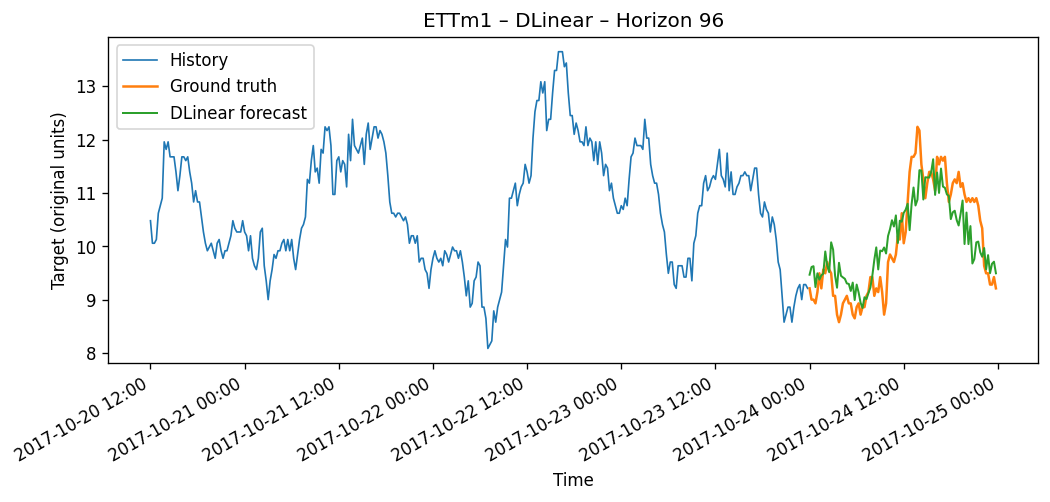

[ETTm1] DLinear – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.003701
MAE (scaled): 0.050394
DTW (scaled): 2.426866
TDI (scaled): 0.050236


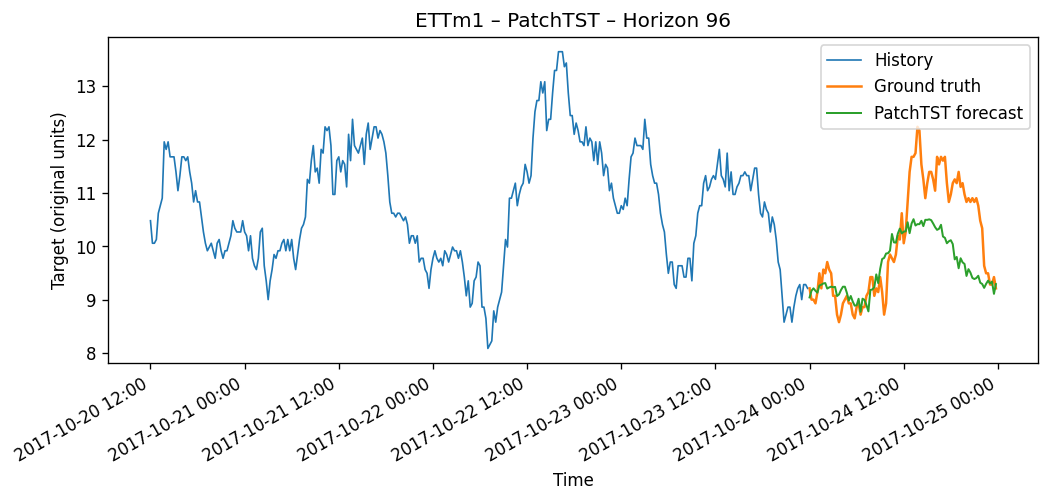

[ETTm1] PatchTST – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.008144
MAE (scaled): 0.068570
DTW (scaled): 4.404460
TDI (scaled): 0.070124


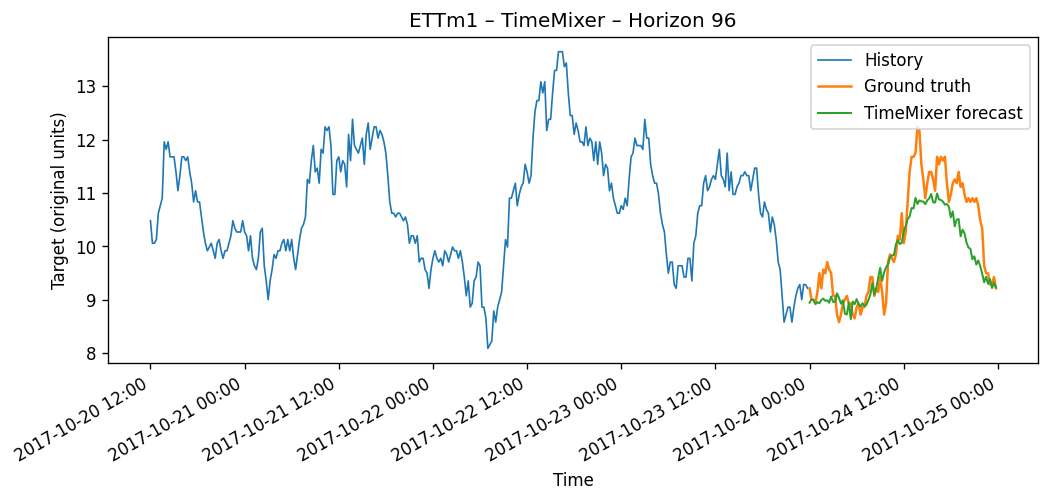

[ETTm1] TimeMixer – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.003704
MAE (scaled): 0.046862
DTW (scaled): 2.679372
TDI (scaled): 0.054107


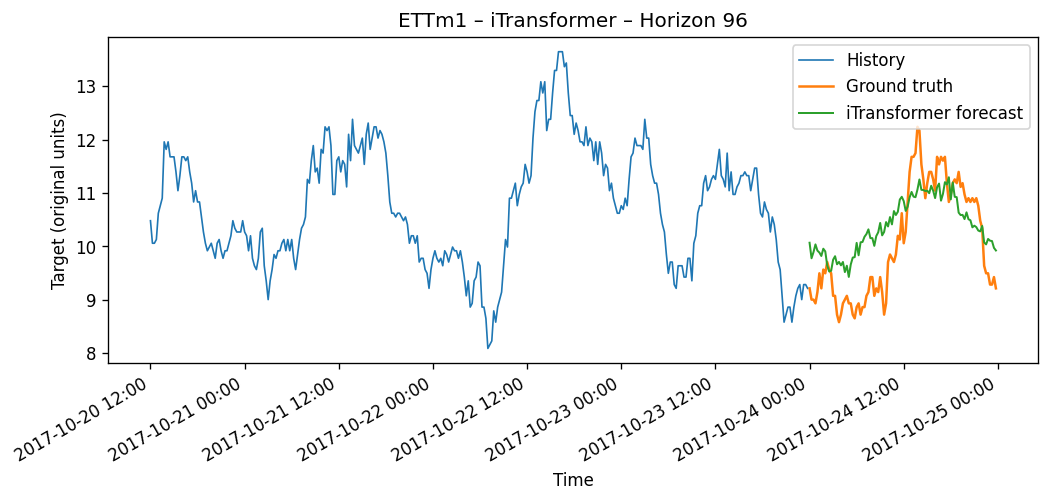

[ETTm1] iTransformer – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.006364
MAE (scaled): 0.069624
DTW (scaled): 3.997383
TDI (scaled): 0.066142

Dataset: ETTm2
[ETTm2] INFO: dataset length 69680 > LTSF total 57600. Using first 57600 points and ignoring extra tail.
Using columns for quantiles -> lower: 0.1, median: predictions, upper: 0.9


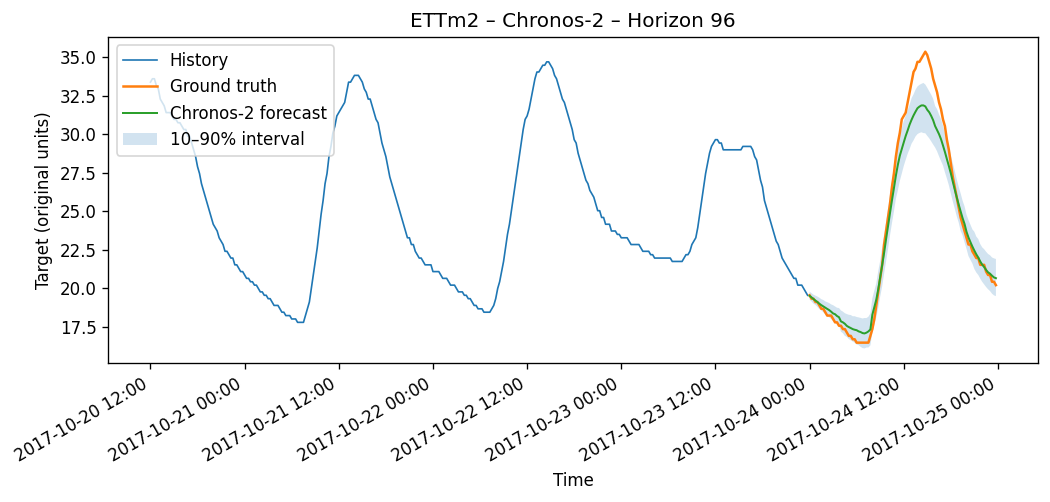

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


[ETTm2] Chronos-2 – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.013779
MAE (scaled): 0.081038
DTW (scaled): 4.553689
TDI (scaled): 0.026173


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train  │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler        │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ decomp        │ SeriesDecomp  │      0 │ train │     0 │
│ 4 │ linear_trend  │ Linear        │ 32.4 K │ train │     0 │
│ 5 │ linear_season │ Linear        │ 32.4 K │ train │     0 │
└───┴───────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 64.7 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 64.7 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

Output()

INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.rich_model_summary.RichModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.rich_model_summary.RichModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

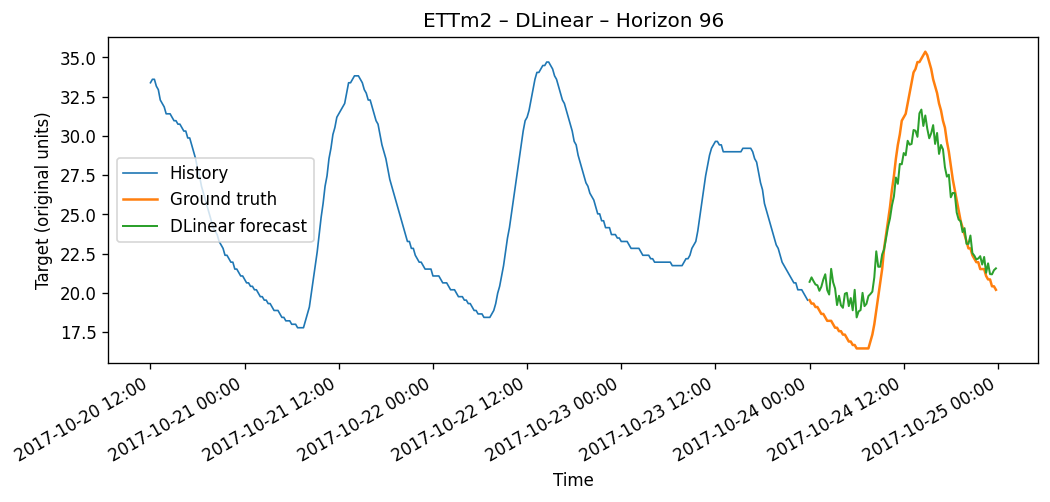

[ETTm2] DLinear – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.040945
MAE (scaled): 0.170863
DTW (scaled): 9.606077
TDI (scaled): 0.057256


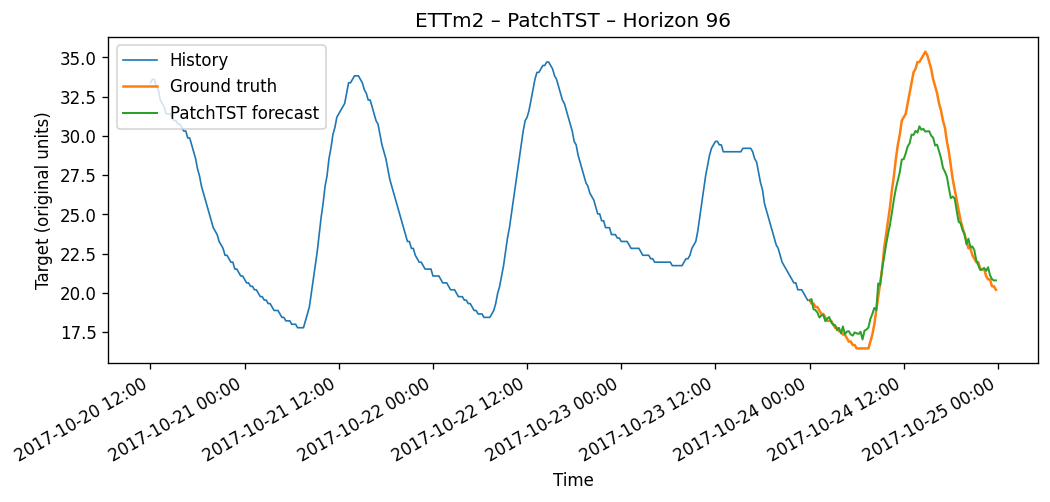

[ETTm2] PatchTST – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.029336
MAE (scaled): 0.117439
DTW (scaled): 7.040397
TDI (scaled): 0.033365


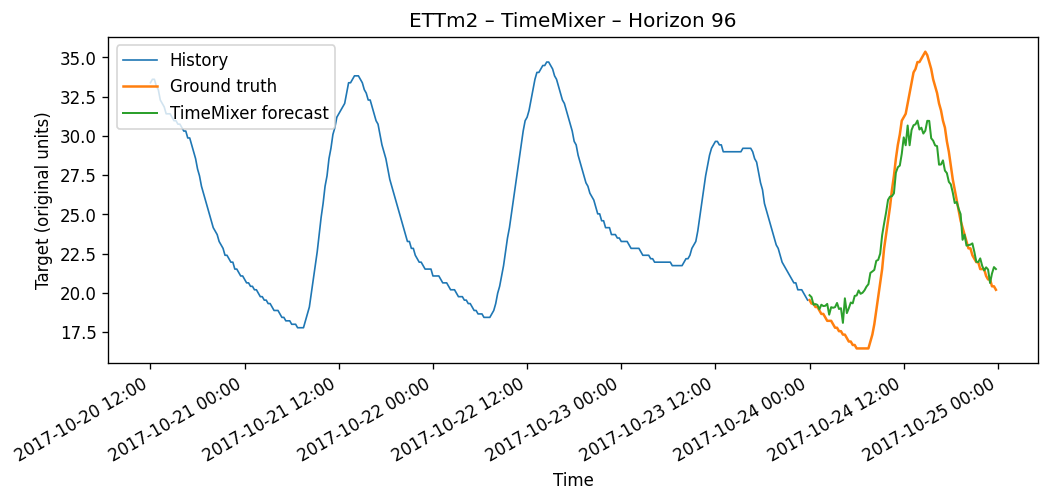

[ETTm2] TimeMixer – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.041825
MAE (scaled): 0.161551
DTW (scaled): 8.806884
TDI (scaled): 0.054050


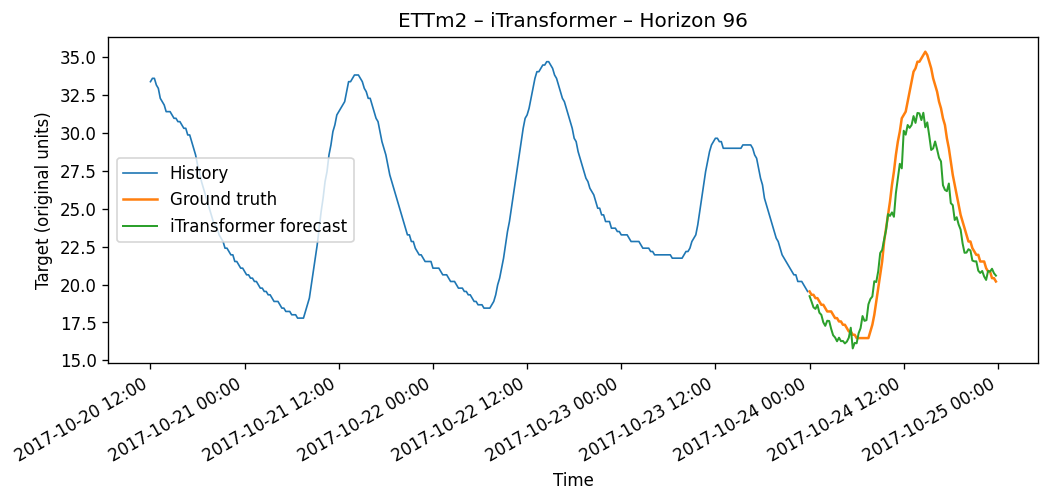

[ETTm2] iTransformer – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.034831
MAE (scaled): 0.146573
DTW (scaled): 6.033302
TDI (scaled): 0.049777

Dataset: Weather
[Weather] WARNING: irregular timestamps; using regular freq '10min'
[Weather] INFO: dataset length 52696 > LTSF total 52603. Using first 52603 points and ignoring extra tail.
Using columns for quantiles -> lower: 0.1, median: predictions, upper: 0.9


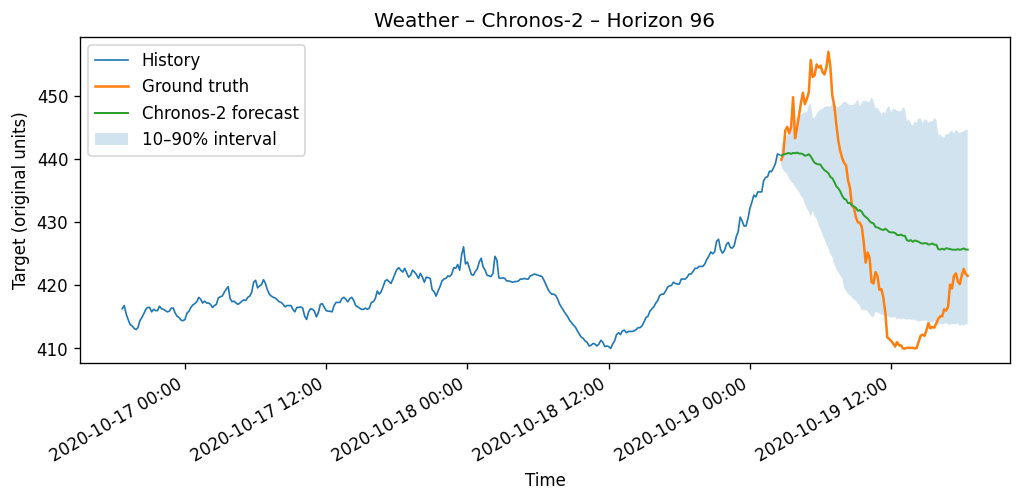

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


[Weather] Chronos-2 – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.000874
MAE (scaled): 0.025876
DTW (scaled): 2.133311
TDI (scaled): 0.129621


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train  │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler        │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ decomp        │ SeriesDecomp  │      0 │ train │     0 │
│ 4 │ linear_trend  │ Linear        │ 32.4 K │ train │     0 │
│ 5 │ linear_season │ Linear        │ 32.4 K │ train │     0 │
└───┴───────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 64.7 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 64.7 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

Output()

INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.rich_model_summary.RichModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.rich_model_summary.RichModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

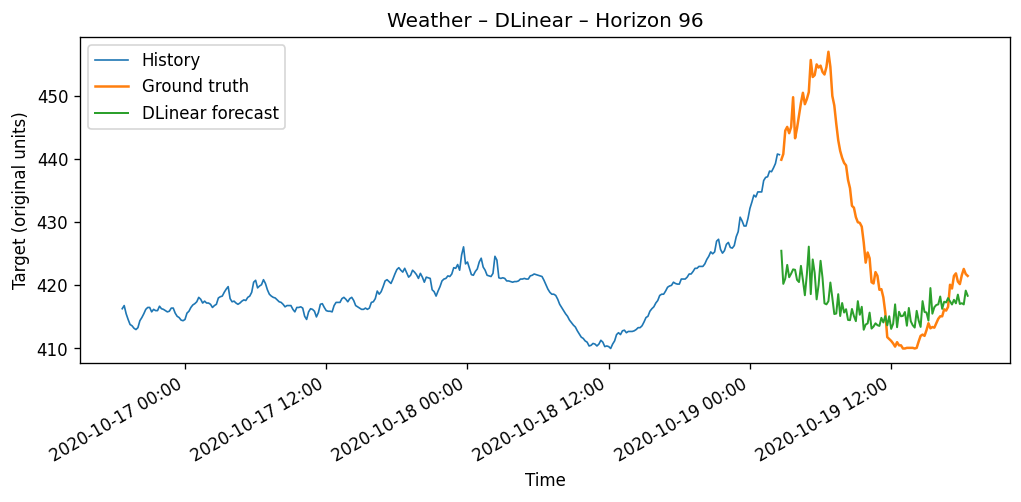

[Weather] DLinear – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.002243
MAE (scaled): 0.035854
DTW (scaled): 2.590452
TDI (scaled): 0.204733


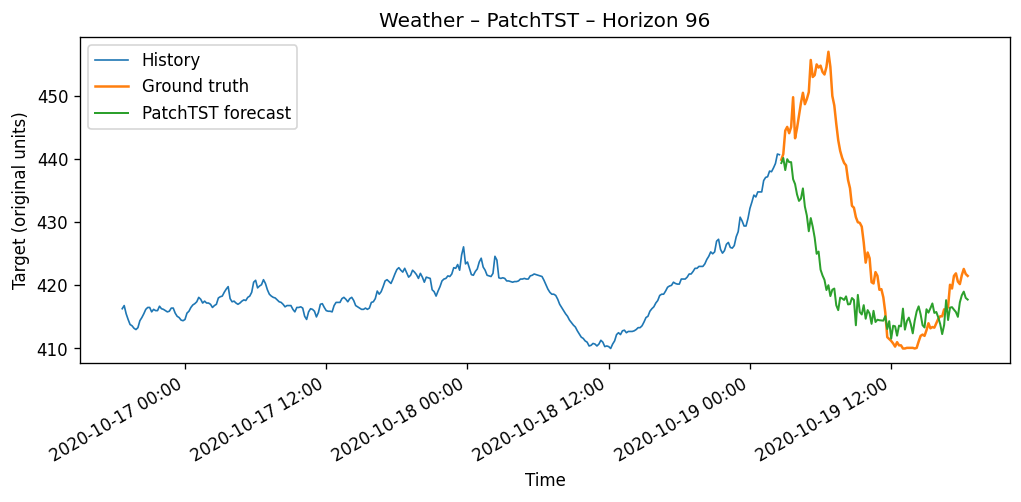

[Weather] PatchTST – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.001493
MAE (scaled): 0.027868
DTW (scaled): 1.055660
TDI (scaled): 0.139288


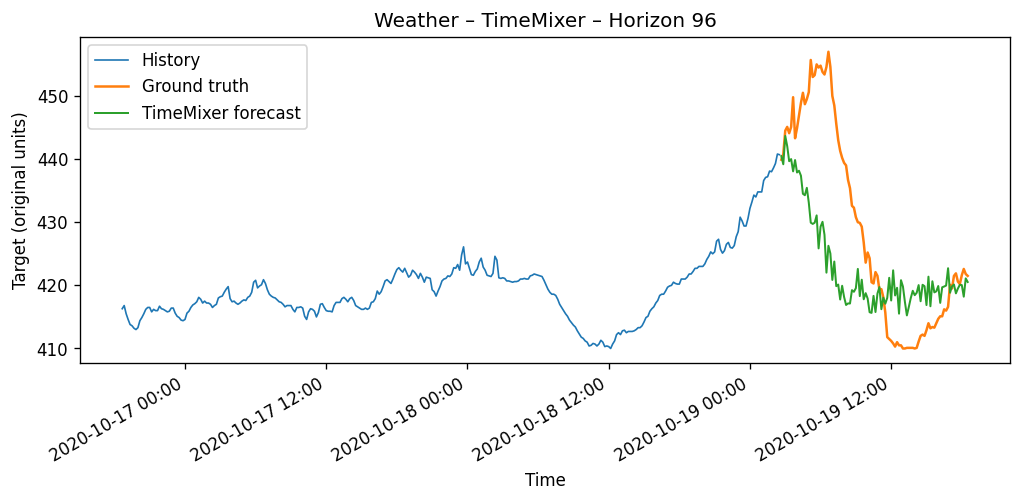

[Weather] TimeMixer – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.001221
MAE (scaled): 0.026781
DTW (scaled): 1.044244
TDI (scaled): 0.183427


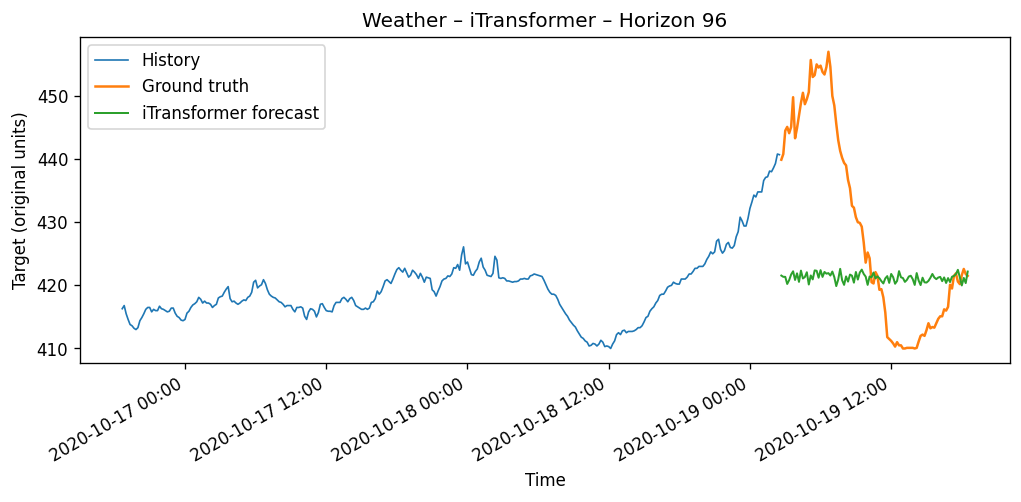

[Weather] iTransformer – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.002048
MAE (scaled): 0.035740
DTW (scaled): 3.383260
TDI (scaled): 0.031798

Dataset: ESNet
[ESNet] n=69082, horizon_days=15, pred_len=4321, n_train=51808, n_val=12953, n_test=4321, test_start_idx=64761, test_start_ts=2025-02-03 06:25:01


/usr/local/lib/python3.12/dist-packages/chronos/chronos2/pipeline.py:601: UserWarning: We recommend keeping prediction length <= 1024. The quality of longer predictions may degrade since the model is not optimized for it. 
  warnings.warn(msg)


Using columns for quantiles -> lower: 0.1, median: predictions, upper: 0.9


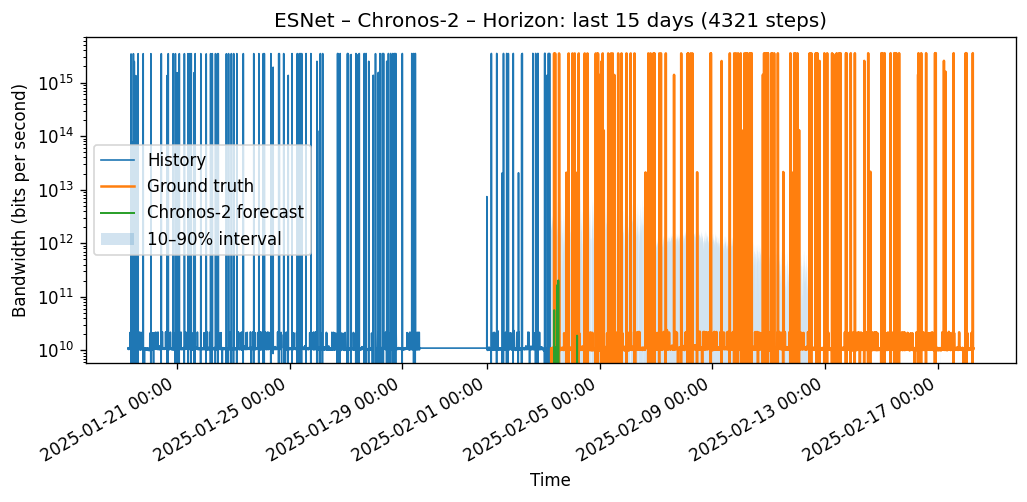

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1


[ESNet] Chronos-2 – single horizon (ALL METRICS SCALED)
MSE (scaled): 1.409463
MAE (scaled): 0.193827
DTW (scaled): 837.525415
TDI (scaled): 0.000364


INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train  │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler        │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ decomp        │ SeriesDecomp  │      0 │ train │     0 │
│ 4 │ linear_trend  │ Linear        │  1.5 M │ train │     0 │
│ 5 │ linear_season │ Linear        │  1.5 M │ train │     0 │
└───┴───────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 2.9 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.9 M                                                                                                
Total estimated model params size (MB): 11                                                                         
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

Output()

INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.rich_model_summary.RichModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.rich_model_summary.RichModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

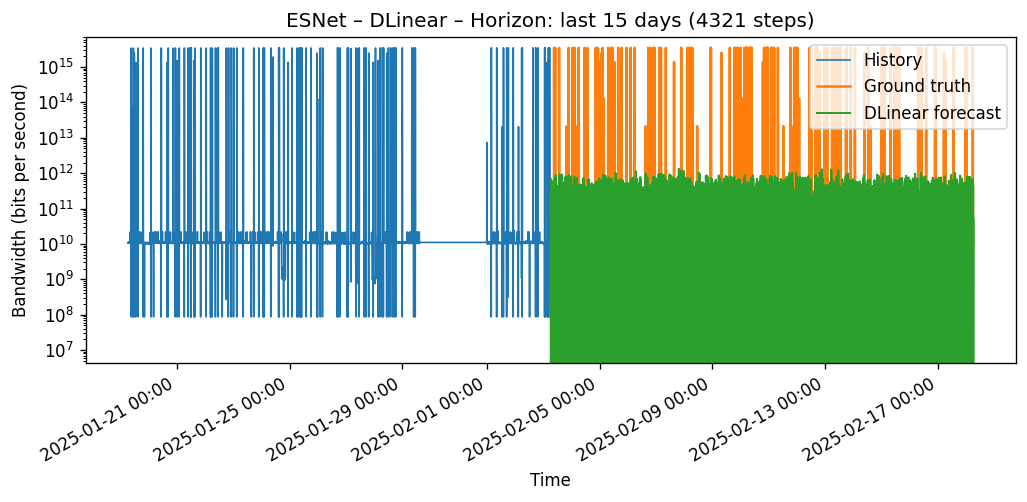

[ESNet] DLinear – single horizon (ALL METRICS SCALED)
MSE (scaled): 1.407201
MAE (scaled): 0.188722
DTW (scaled): 815.415552
TDI (scaled): 0.043592


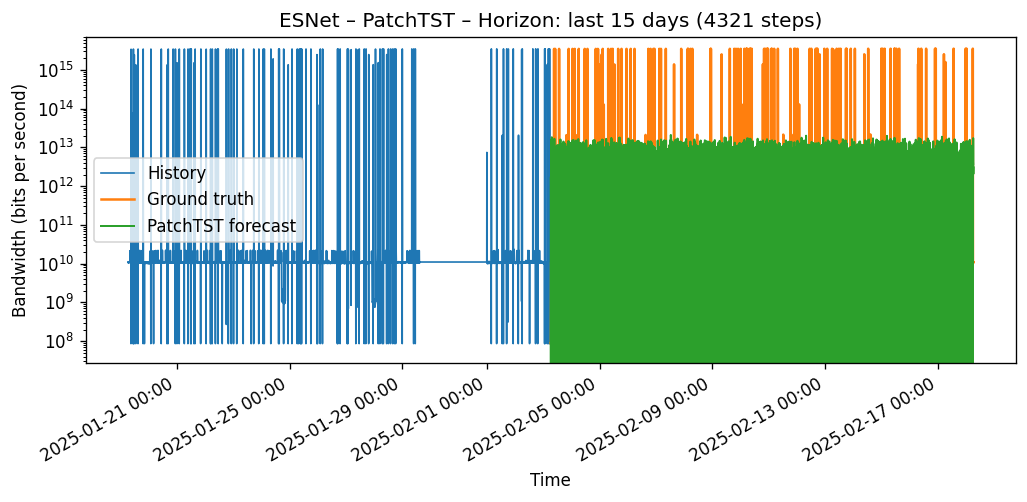

[ESNet] PatchTST – single horizon (ALL METRICS SCALED)
MSE (scaled): 1.404271
MAE (scaled): 0.199130
DTW (scaled): 857.144090
TDI (scaled): 0.021594


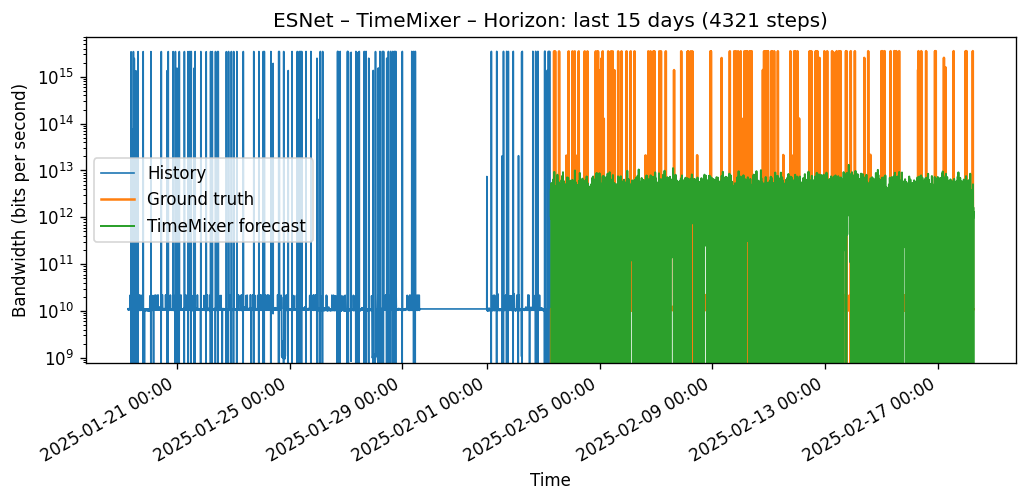

[ESNet] TimeMixer – single horizon (ALL METRICS SCALED)
MSE (scaled): 1.405384
MAE (scaled): 0.194284
DTW (scaled): 837.499411
TDI (scaled): 0.014525
Saved metrics CSV to: results/h96/metrics_h96.csv


,dataset,model,horizon_len,mse_scaled,mae_scaled,dtw_scaled,tdi_scaled,protocol,fig_path
0,ETTh1,Chronos-2,96,0.021393,0.114201,9.930030,0.164855,single_horizon_scaled,results/h96/ETTh1_Chronos-2_h96.png
1,ETTh1,DLinear,96,0.084096,0.235436,19.353409,0.031417,single_horizon_scaled,results/h96/ETTh1_DLinear_h96.png
2,ETTh1,PatchTST,96,0.077577,0.218705,18.591637,0.022146,single_horizon_scaled,results/h96/ETTh1_PatchTST_h96.png
3,ETTh1,TimeMixer,96,0.076842,0.228453,18.715198,0.027462,single_horizon_scaled,results/h96/ETTh1_TimeMixer_h96.png
4,ETTh1,iTransformer,96,0.065914,0.221145,15.971849,0.128353,single_horizon_scaled,results/h96/ETTh1_iTransformer_h96.png
5,ETTm1,Chronos-2,96,0.005150,0.062643,4.032826,0.115411,single_horizon_scaled,results/h96/ETTm1_Chronos-2_h96.png
6,ETTm1,DLinear,96,0.003701,0.050394,2.426866,0.050236,single_horizon_scaled,results/h96/ETTm1_DLinear_h96.png
7,ETTm1,PatchTST,96,0.008144,0.068570,4.404460,0.070124,single_horizon_scaled,results/h96/ETTm1_PatchTST_h96.png
8,ETTm1,TimeMixer,96,0.003704,0.046862,2.679372,0.054107,single_horizon_scaled,results/h96/ETTm1_TimeMixer_h96.png
9,ETTm1,iTransformer,96,0.006364,0.069624,3.997383,0.066142,single_horizon_scaled,results/h96/ETTm1_iTransformer_h96.png


In [19]:
PREDICTION_LENGTH = 96
all_results = []

RESULTS_SUBDIR = os.path.join(BASE_RESULTS_DIR, f"h{PREDICTION_LENGTH}")
os.makedirs(RESULTS_SUBDIR, exist_ok=True)
print("Saving results to:", RESULTS_SUBDIR)

for ds_name, path in DATASETS.items():
    print("\n" + "=" * 80)
    print(f"Dataset: {ds_name}")
    dataset = prepare_dataset(ds_name, path)

    # Chronos-2
    chr_pred_scaled, chr_lower_scaled, chr_upper_scaled = chronos_predict_scaled(
        dataset, pipeline
    )
    res = plot_and_metrics(
        dataset,
        "Chronos-2",
        chr_pred_scaled,
        lower_scaled=chr_lower_scaled,
        upper_scaled=chr_upper_scaled,
        results_dir=RESULTS_SUBDIR,
    )
    all_results.append(res)

    # NeuralForecast models
    nf_preds = nf_predict_scaled(dataset)
    for model_name, pred_scaled in nf_preds.items():
        res = plot_and_metrics(
            dataset,
            model_name,
            pred_scaled,
            results_dir=RESULTS_SUBDIR,
        )
        all_results.append(res)

metrics_df = pd.DataFrame(all_results)

csv_path = os.path.join(RESULTS_SUBDIR, f"metrics_h{PREDICTION_LENGTH}.csv")
metrics_df.to_csv(csv_path, index=False)
print("Saved metrics CSV to:", csv_path)

metrics_df

Saving results to: results/h336

Dataset: ETTh1
[ETTh1] INFO: dataset length 17420 > LTSF total 14400. Using first 14400 points and ignoring extra tail.
Using columns for quantiles -> lower: 0.1, median: predictions, upper: 0.9


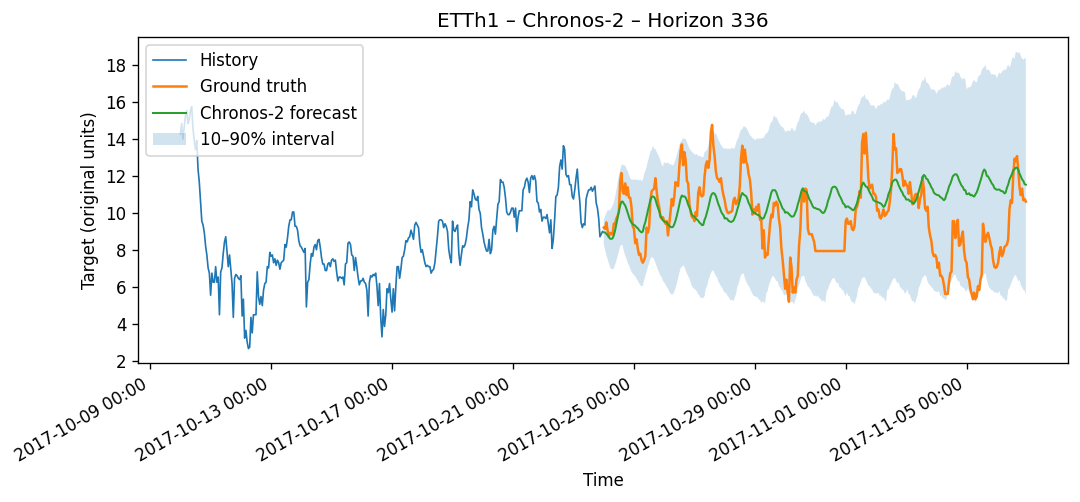

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1


[ETTh1] Chronos-2 – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.062555
MAE (scaled): 0.193179
DTW (scaled): 56.808196
TDI (scaled): 0.154187


INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train  │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler        │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ decomp        │ SeriesDecomp  │      0 │ train │     0 │
│ 4 │ linear_trend  │ Linear        │  113 K │ train │     0 │
│ 5 │ linear_season │ Linear        │  113 K │ train │     0 │
└───┴───────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 226 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 226 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

Output()

INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.rich_model_summary.RichModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.rich_model_summary.RichModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

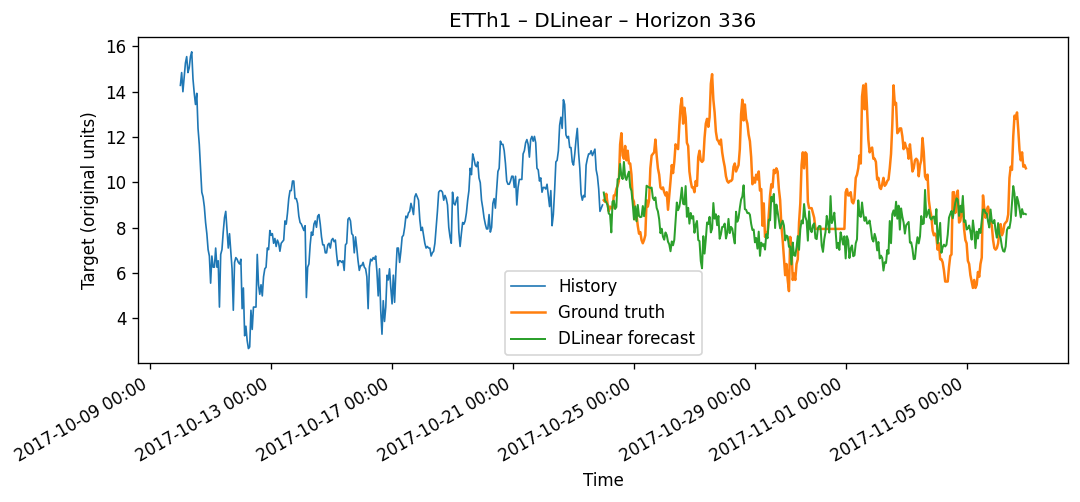

[ETTh1] DLinear – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.072201
MAE (scaled): 0.218863
DTW (scaled): 48.260837
TDI (scaled): 0.333085


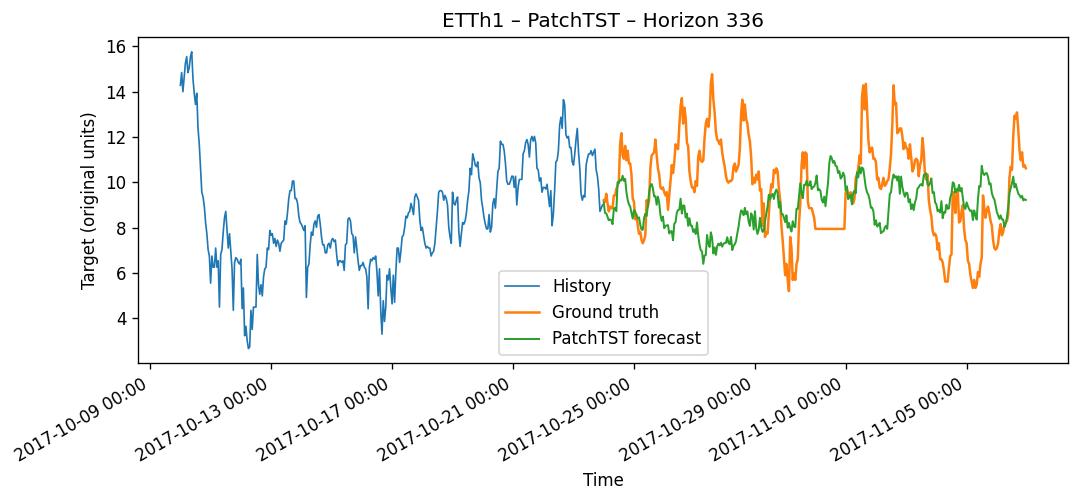

[ETTh1] PatchTST – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.068439
MAE (scaled): 0.217116
DTW (scaled): 44.586493
TDI (scaled): 0.118205


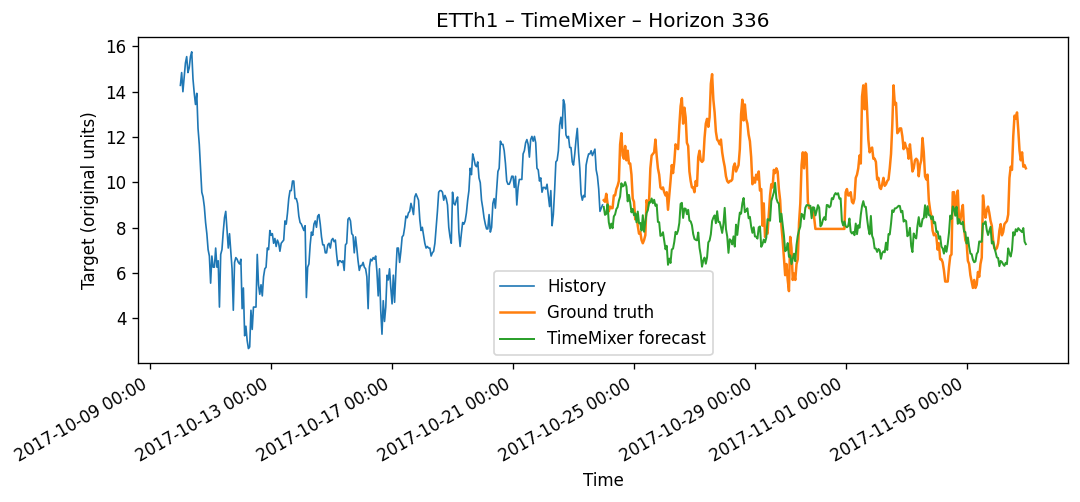

[ETTh1] TimeMixer – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.077365
MAE (scaled): 0.226700
DTW (scaled): 52.932545
TDI (scaled): 0.138011


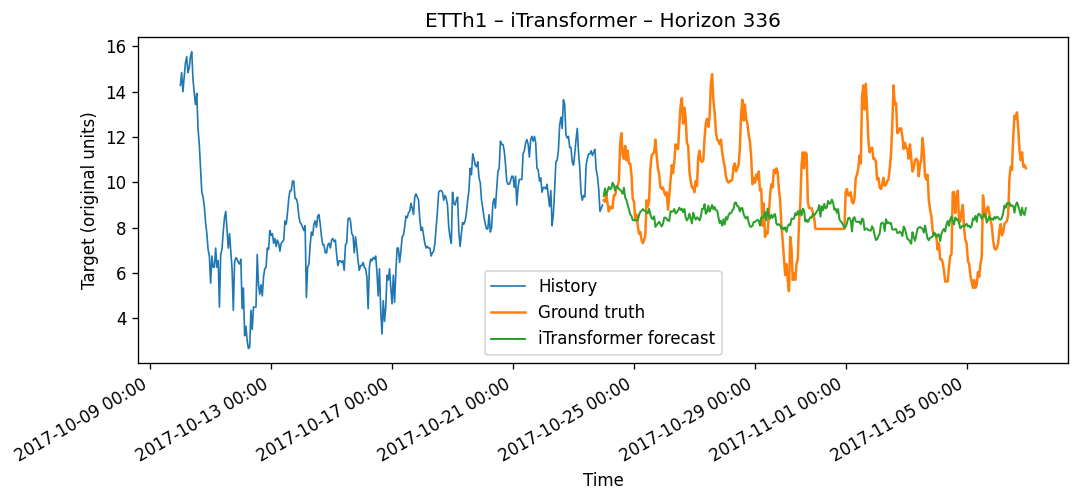

[ETTh1] iTransformer – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.070365
MAE (scaled): 0.218404
DTW (scaled): 50.784932
TDI (scaled): 0.168984

Dataset: ETTm1
[ETTm1] INFO: dataset length 69680 > LTSF total 57600. Using first 57600 points and ignoring extra tail.
Using columns for quantiles -> lower: 0.1, median: predictions, upper: 0.9


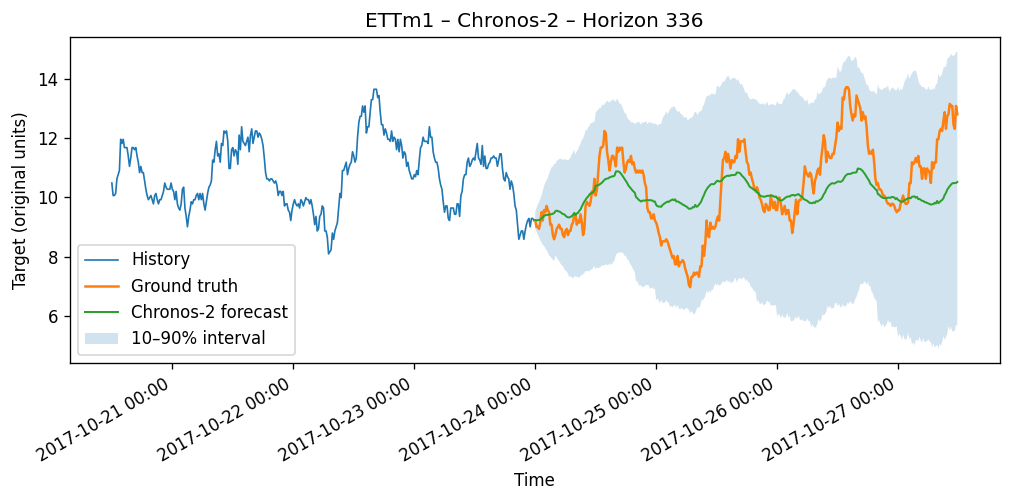

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


[ETTm1] Chronos-2 – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.018342
MAE (scaled): 0.107346
DTW (scaled): 28.237853
TDI (scaled): 0.039199


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train  │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler        │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ decomp        │ SeriesDecomp  │      0 │ train │     0 │
│ 4 │ linear_trend  │ Linear        │  113 K │ train │     0 │
│ 5 │ linear_season │ Linear        │  113 K │ train │     0 │
└───┴───────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 226 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 226 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

Output()

INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.rich_model_summary.RichModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.rich_model_summary.RichModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

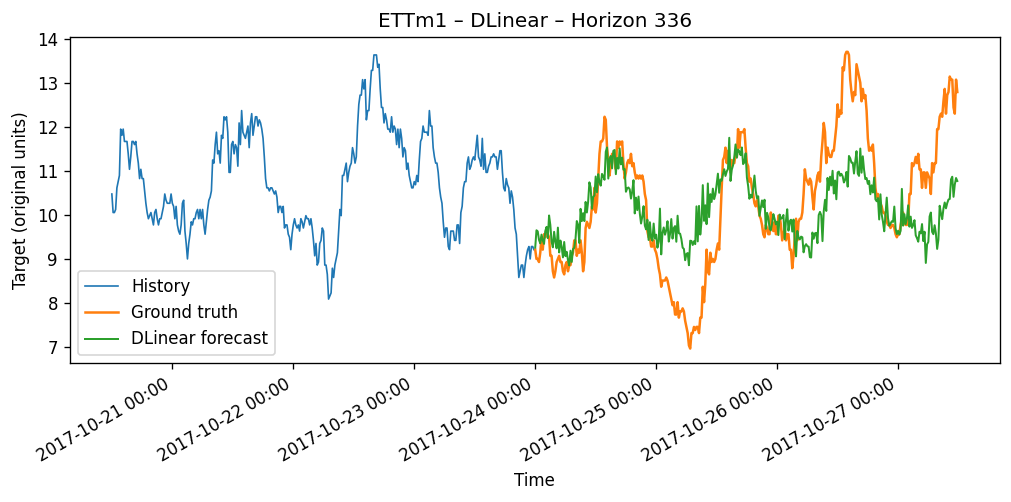

[ETTm1] DLinear – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.016459
MAE (scaled): 0.099305
DTW (scaled): 19.360833
TDI (scaled): 0.029826


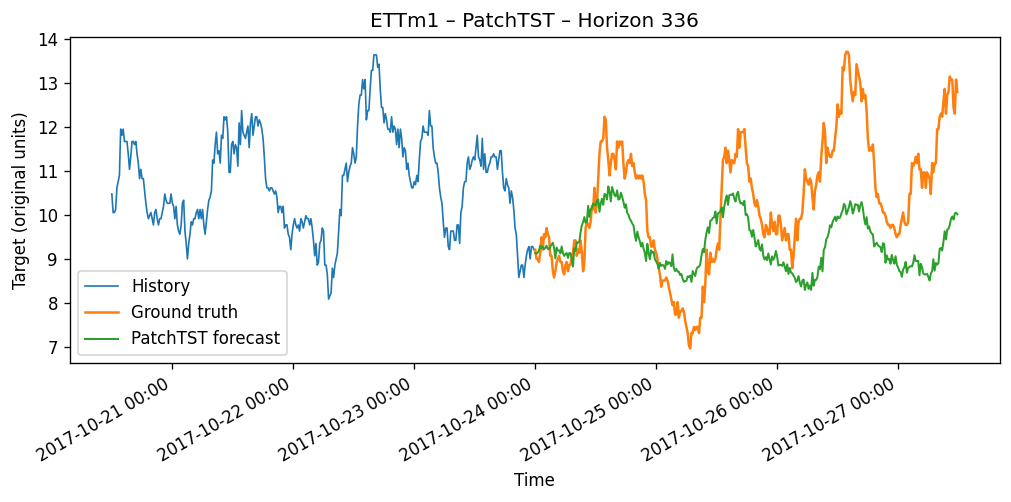

[ETTm1] PatchTST – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.028543
MAE (scaled): 0.138659
DTW (scaled): 31.978200
TDI (scaled): 0.037488


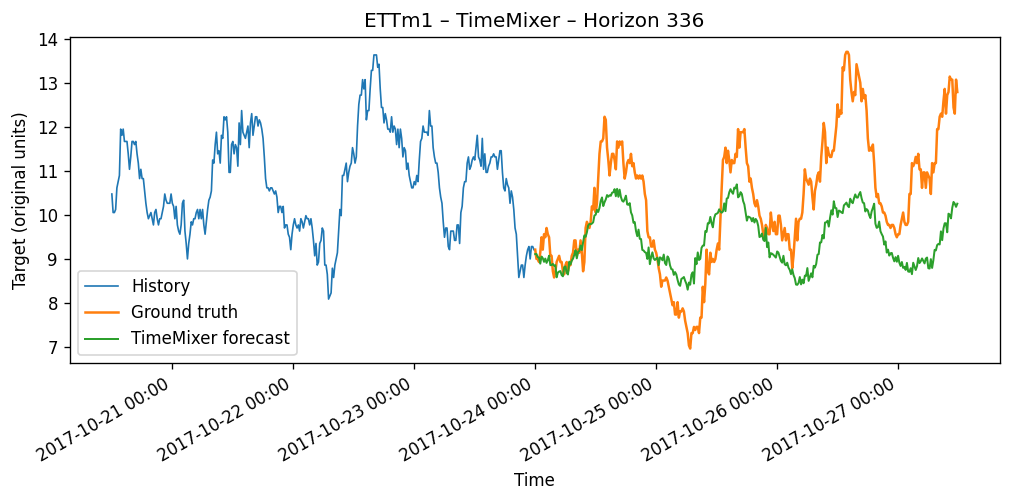

[ETTm1] TimeMixer – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.024260
MAE (scaled): 0.126119
DTW (scaled): 27.583084
TDI (scaled): 0.034861


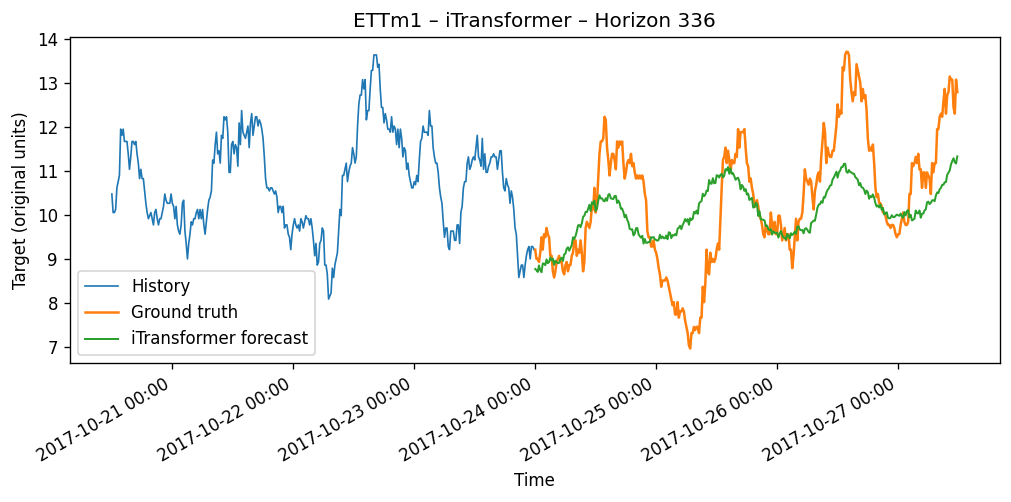

[ETTm1] iTransformer – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.017288
MAE (scaled): 0.102841
DTW (scaled): 23.768294
TDI (scaled): 0.040500

Dataset: ETTm2
[ETTm2] INFO: dataset length 69680 > LTSF total 57600. Using first 57600 points and ignoring extra tail.
Using columns for quantiles -> lower: 0.1, median: predictions, upper: 0.9


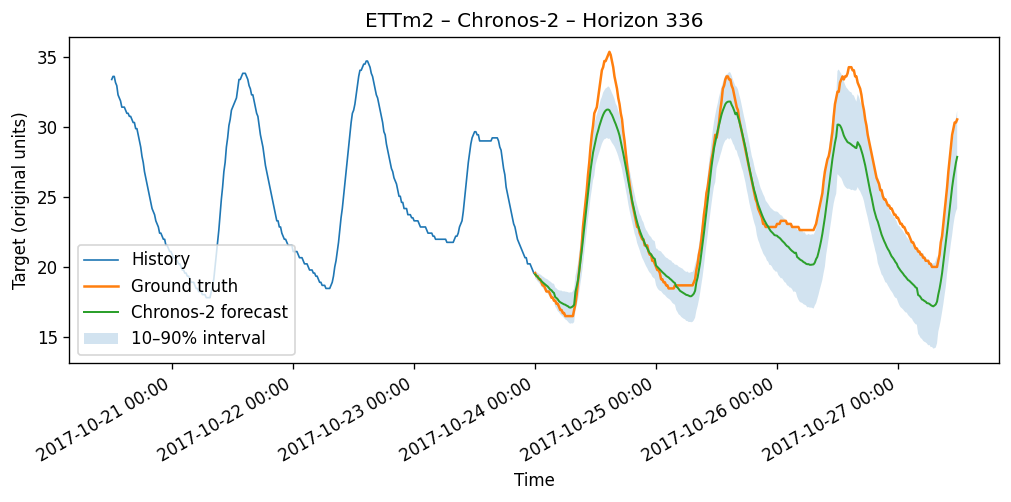

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


[ETTm2] Chronos-2 – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.037598
MAE (scaled): 0.151727
DTW (scaled): 26.916285
TDI (scaled): 0.020938


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train  │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler        │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ decomp        │ SeriesDecomp  │      0 │ train │     0 │
│ 4 │ linear_trend  │ Linear        │  113 K │ train │     0 │
│ 5 │ linear_season │ Linear        │  113 K │ train │     0 │
└───┴───────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 226 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 226 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

Output()

INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.rich_model_summary.RichModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.rich_model_summary.RichModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

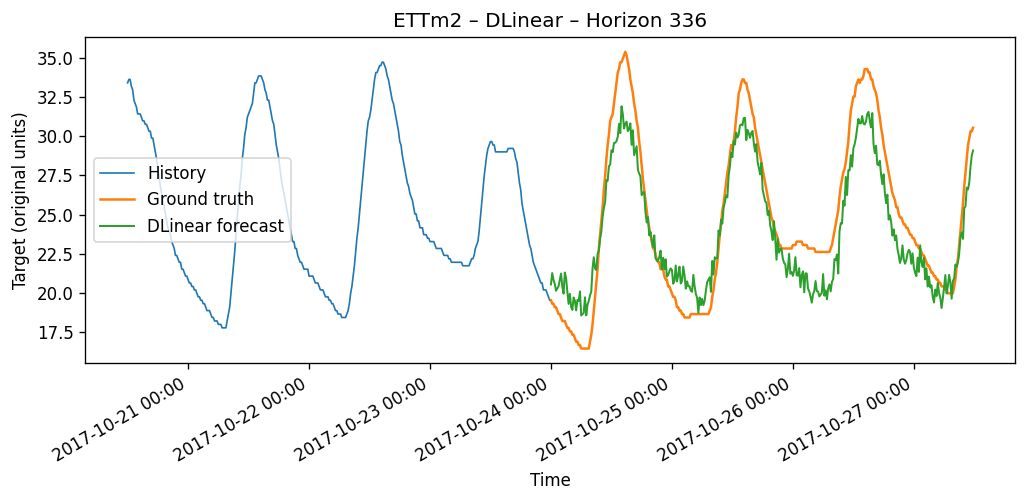

[ETTm2] DLinear – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.032553
MAE (scaled): 0.156087
DTW (scaled): 28.177196
TDI (scaled): 0.021003


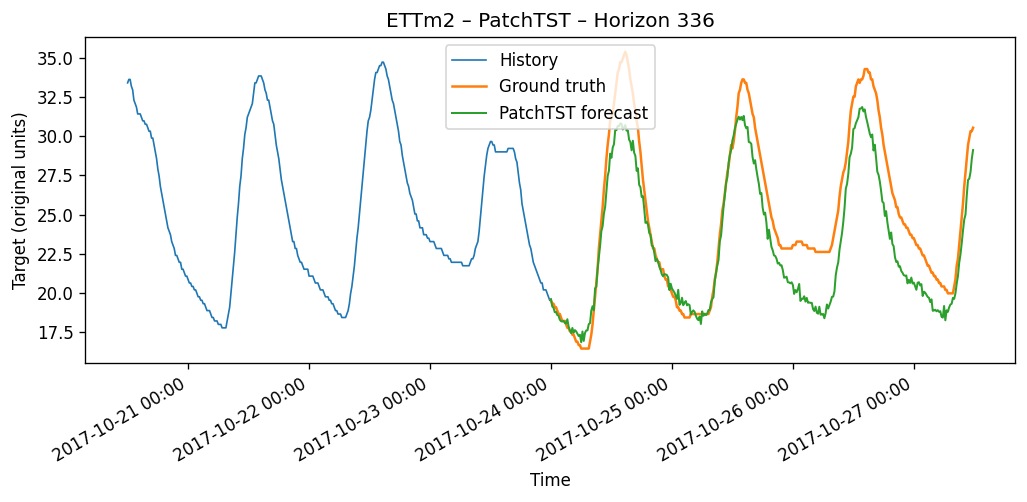

[ETTm2] PatchTST – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.040193
MAE (scaled): 0.164233
DTW (scaled): 27.650952
TDI (scaled): 0.018969


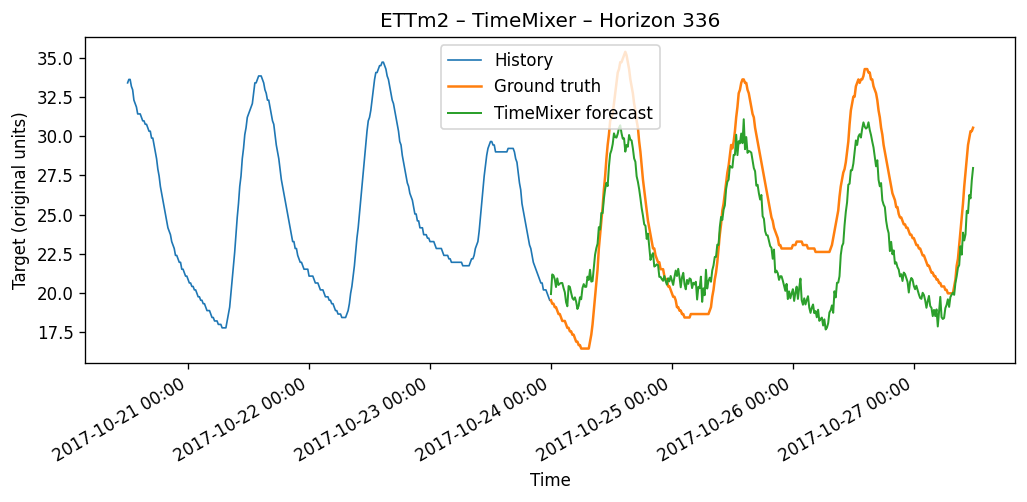

[ETTm2] TimeMixer – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.063949
MAE (scaled): 0.228008
DTW (scaled): 40.915726
TDI (scaled): 0.028067


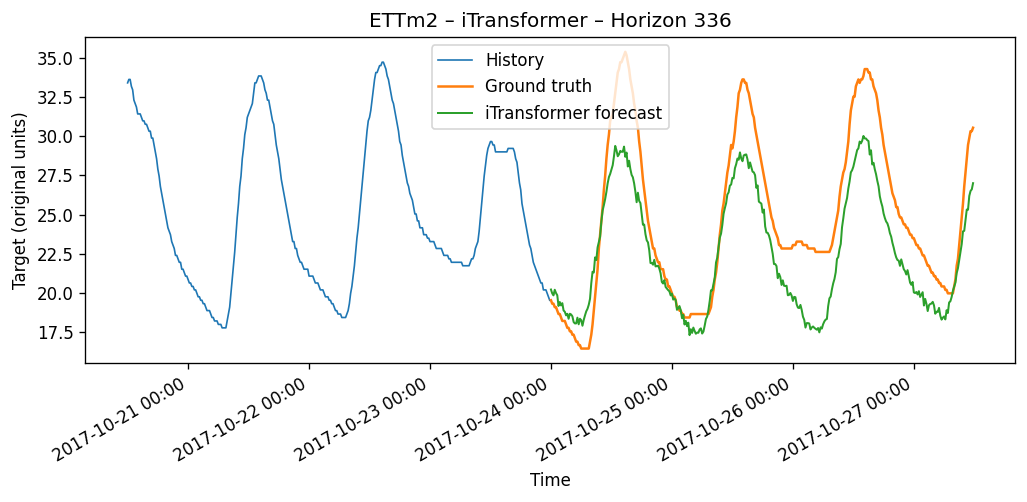

[ETTm2] iTransformer – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.069726
MAE (scaled): 0.223797
DTW (scaled): 45.004046
TDI (scaled): 0.021830

Dataset: Weather
[Weather] WARNING: irregular timestamps; using regular freq '10min'
[Weather] INFO: dataset length 52696 > LTSF total 52603. Using first 52603 points and ignoring extra tail.
Using columns for quantiles -> lower: 0.1, median: predictions, upper: 0.9


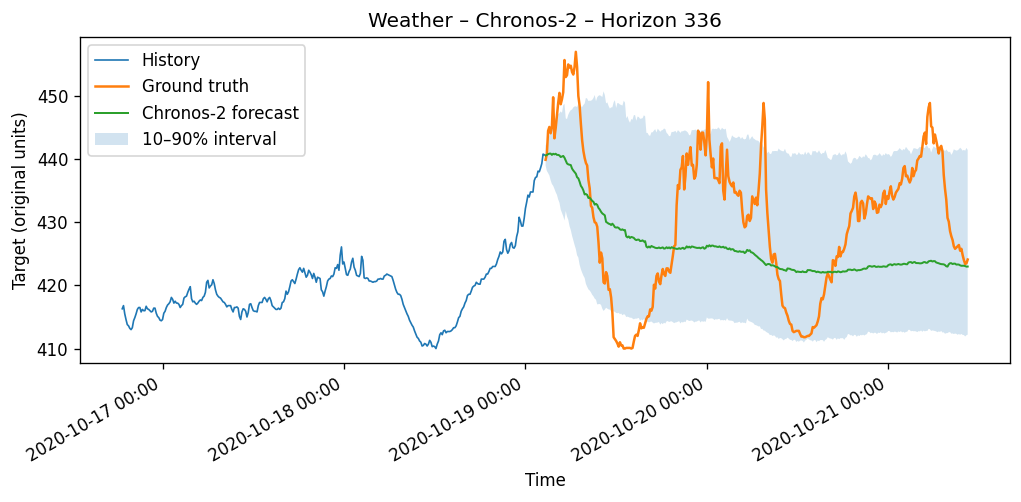

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


[Weather] Chronos-2 – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.000886
MAE (scaled): 0.025922
DTW (scaled): 8.058503
TDI (scaled): 0.050091


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train  │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler        │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ decomp        │ SeriesDecomp  │      0 │ train │     0 │
│ 4 │ linear_trend  │ Linear        │  113 K │ train │     0 │
│ 5 │ linear_season │ Linear        │  113 K │ train │     0 │
└───┴───────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 226 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 226 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

Output()

INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.rich_model_summary.RichModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.rich_model_summary.RichModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

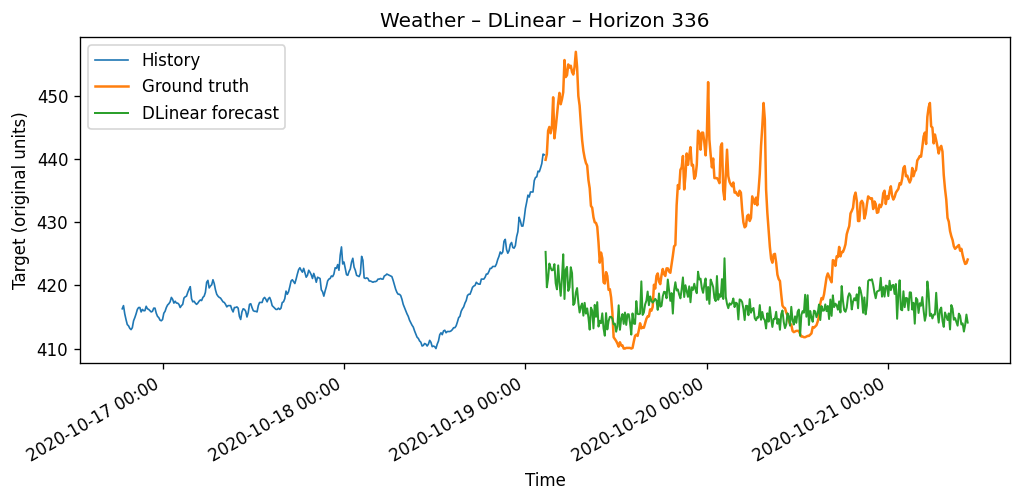

[Weather] DLinear – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.001956
MAE (scaled): 0.037073
DTW (scaled): 10.577778
TDI (scaled): 0.055308


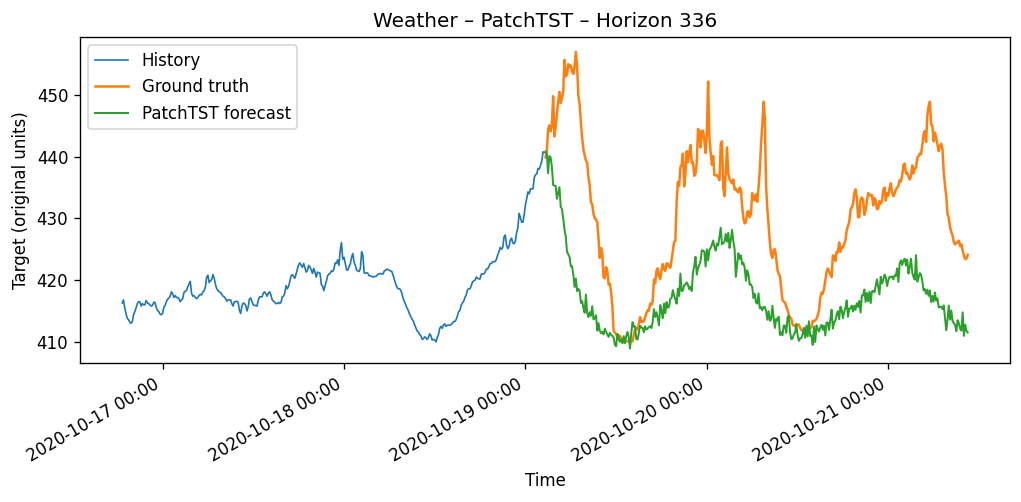

[Weather] PatchTST – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.001580
MAE (scaled): 0.033423
DTW (scaled): 6.662072
TDI (scaled): 0.056439


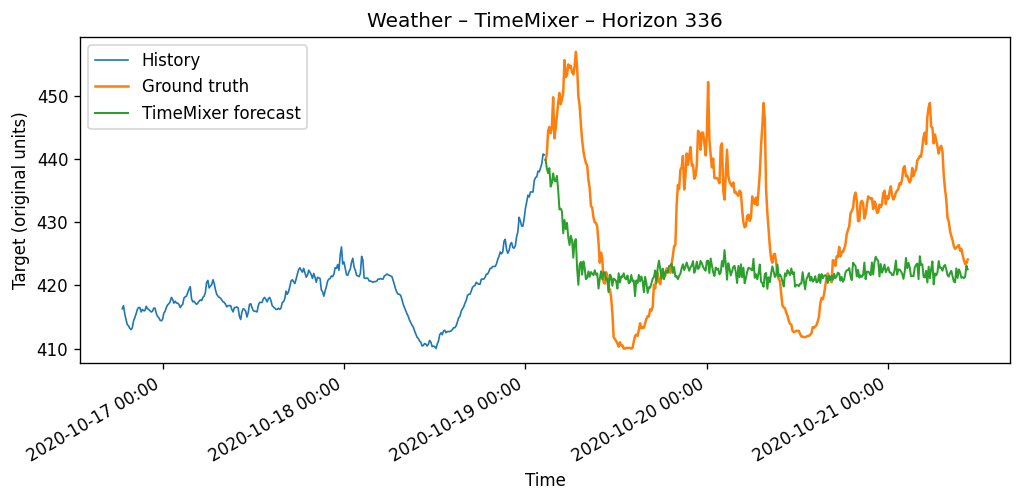

[Weather] TimeMixer – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.001136
MAE (scaled): 0.028369
DTW (scaled): 7.709708
TDI (scaled): 0.039357


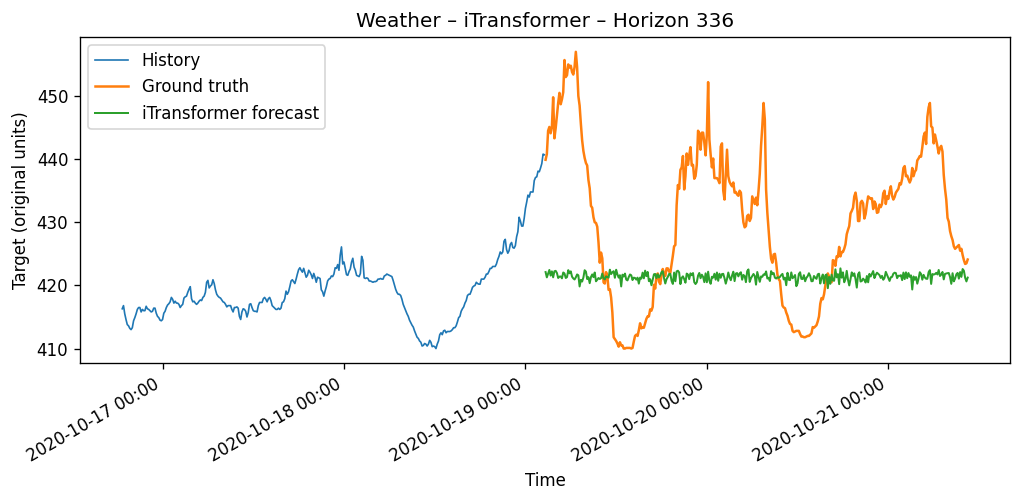

[Weather] iTransformer – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.001462
MAE (scaled): 0.032028
DTW (scaled): 10.457162
TDI (scaled): 0.063153

Dataset: ESNet
[ESNet] n=69082, horizon_days=15, pred_len=4321, n_train=51808, n_val=12953, n_test=4321, test_start_idx=64761, test_start_ts=2025-02-03 06:25:01


/usr/local/lib/python3.12/dist-packages/chronos/chronos2/pipeline.py:601: UserWarning: We recommend keeping prediction length <= 1024. The quality of longer predictions may degrade since the model is not optimized for it. 
  warnings.warn(msg)


Using columns for quantiles -> lower: 0.1, median: predictions, upper: 0.9


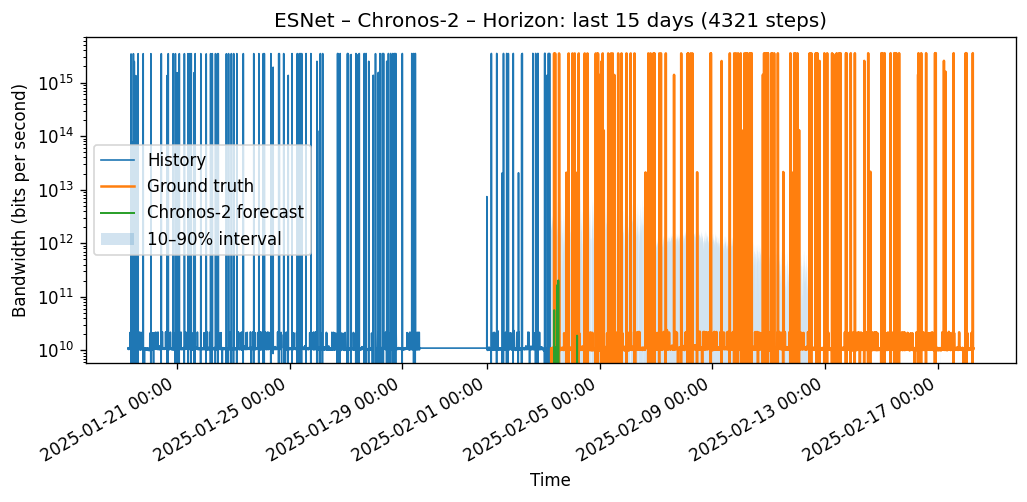

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1


[ESNet] Chronos-2 – single horizon (ALL METRICS SCALED)
MSE (scaled): 1.409463
MAE (scaled): 0.193827
DTW (scaled): 837.525415
TDI (scaled): 0.000364


INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train  │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler        │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ decomp        │ SeriesDecomp  │      0 │ train │     0 │
│ 4 │ linear_trend  │ Linear        │  1.5 M │ train │     0 │
│ 5 │ linear_season │ Linear        │  1.5 M │ train │     0 │
└───┴───────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 2.9 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.9 M                                                                                                
Total estimated model params size (MB): 11                                                                         
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

Output()

INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.rich_model_summary.RichModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.rich_model_summary.RichModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

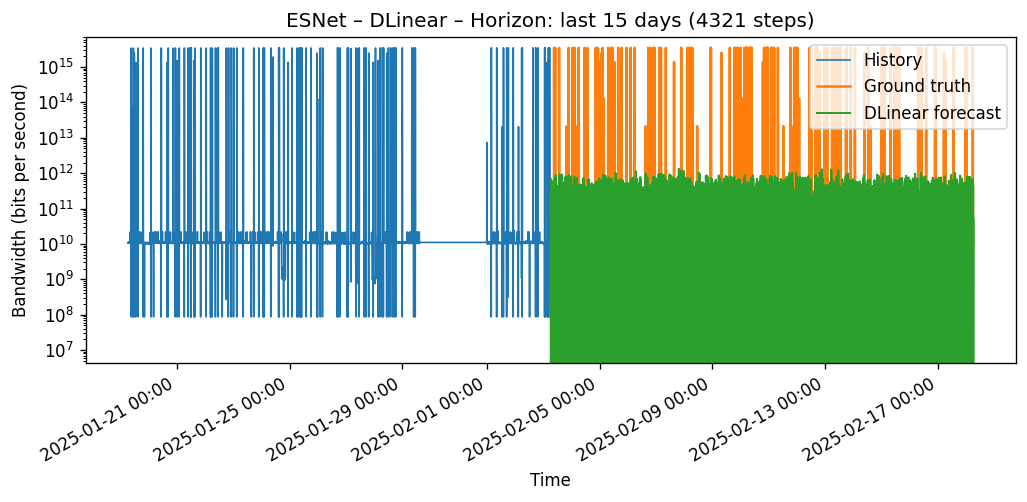

[ESNet] DLinear – single horizon (ALL METRICS SCALED)
MSE (scaled): 1.407201
MAE (scaled): 0.188722
DTW (scaled): 815.415552
TDI (scaled): 0.043592


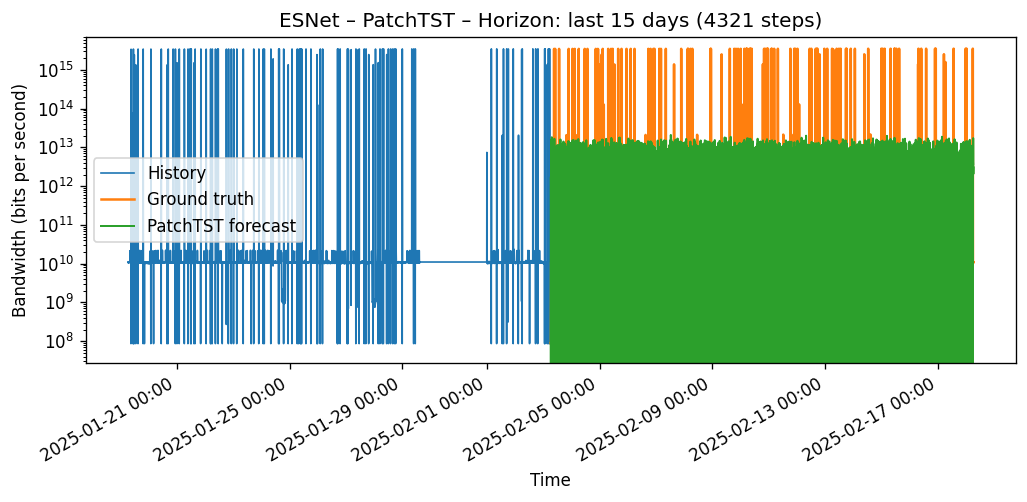

[ESNet] PatchTST – single horizon (ALL METRICS SCALED)
MSE (scaled): 1.404271
MAE (scaled): 0.199130
DTW (scaled): 857.144090
TDI (scaled): 0.021594


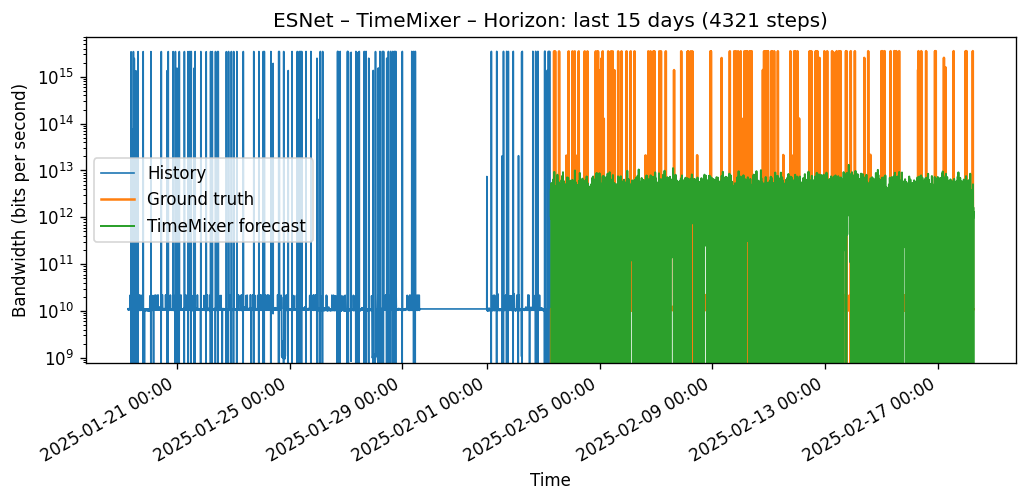

[ESNet] TimeMixer – single horizon (ALL METRICS SCALED)
MSE (scaled): 1.405384
MAE (scaled): 0.194284
DTW (scaled): 837.499411
TDI (scaled): 0.014525
Saved metrics CSV to: results/h336/metrics_h336.csv


,dataset,model,horizon_len,mse_scaled,mae_scaled,dtw_scaled,tdi_scaled,protocol,fig_path
0,ETTh1,Chronos-2,336,0.062555,0.193179,56.808196,0.154187,single_horizon_scaled,results/h336/ETTh1_Chronos-2_h336.png
1,ETTh1,DLinear,336,0.072201,0.218863,48.260837,0.333085,single_horizon_scaled,results/h336/ETTh1_DLinear_h336.png
2,ETTh1,PatchTST,336,0.068439,0.217116,44.586493,0.118205,single_horizon_scaled,results/h336/ETTh1_PatchTST_h336.png
3,ETTh1,TimeMixer,336,0.077365,0.226700,52.932545,0.138011,single_horizon_scaled,results/h336/ETTh1_TimeMixer_h336.png
4,ETTh1,iTransformer,336,0.070365,0.218404,50.784932,0.168984,single_horizon_scaled,results/h336/ETTh1_iTransformer_h336.png
5,ETTm1,Chronos-2,336,0.018342,0.107346,28.237853,0.039199,single_horizon_scaled,results/h336/ETTm1_Chronos-2_h336.png
6,ETTm1,DLinear,336,0.016459,0.099305,19.360833,0.029826,single_horizon_scaled,results/h336/ETTm1_DLinear_h336.png
7,ETTm1,PatchTST,336,0.028543,0.138659,31.978200,0.037488,single_horizon_scaled,results/h336/ETTm1_PatchTST_h336.png
8,ETTm1,TimeMixer,336,0.024260,0.126119,27.583084,0.034861,single_horizon_scaled,results/h336/ETTm1_TimeMixer_h336.png
9,ETTm1,iTransformer,336,0.017288,0.102841,23.768294,0.040500,single_horizon_scaled,results/h336/ETTm1_iTransformer_h336.png


In [20]:
PREDICTION_LENGTH = 336
all_results = []

RESULTS_SUBDIR = os.path.join(BASE_RESULTS_DIR, f"h{PREDICTION_LENGTH}")
os.makedirs(RESULTS_SUBDIR, exist_ok=True)
print("Saving results to:", RESULTS_SUBDIR)

for ds_name, path in DATASETS.items():
    print("\n" + "=" * 80)
    print(f"Dataset: {ds_name}")
    dataset = prepare_dataset(ds_name, path)

    # Chronos-2
    chr_pred_scaled, chr_lower_scaled, chr_upper_scaled = chronos_predict_scaled(
        dataset, pipeline
    )
    res = plot_and_metrics(
        dataset,
        "Chronos-2",
        chr_pred_scaled,
        lower_scaled=chr_lower_scaled,
        upper_scaled=chr_upper_scaled,
        results_dir=RESULTS_SUBDIR,
    )
    all_results.append(res)

    # NeuralForecast models
    nf_preds = nf_predict_scaled(dataset)
    for model_name, pred_scaled in nf_preds.items():
        res = plot_and_metrics(
            dataset,
            model_name,
            pred_scaled,
            results_dir=RESULTS_SUBDIR,
        )
        all_results.append(res)

metrics_df = pd.DataFrame(all_results)

csv_path = os.path.join(RESULTS_SUBDIR, f"metrics_h{PREDICTION_LENGTH}.csv")
metrics_df.to_csv(csv_path, index=False)
print("Saved metrics CSV to:", csv_path)

metrics_df

Saving results to: results/h720

Dataset: ETTh1
[ETTh1] INFO: dataset length 17420 > LTSF total 14400. Using first 14400 points and ignoring extra tail.
Using columns for quantiles -> lower: 0.1, median: predictions, upper: 0.9


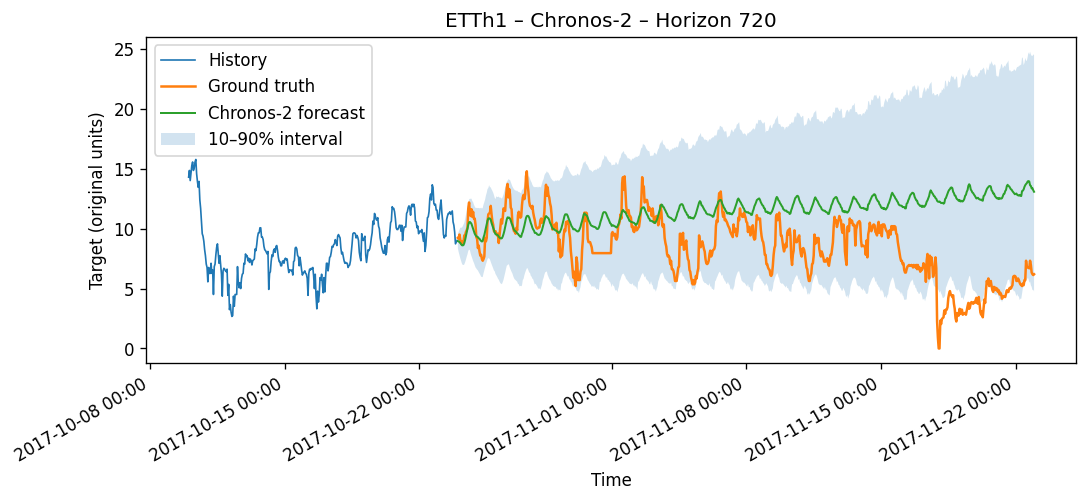

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


[ETTh1] Chronos-2 – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.233049
MAE (scaled): 0.373450
DTW (scaled): 258.413805
TDI (scaled): 0.043094


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train  │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler        │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ decomp        │ SeriesDecomp  │      0 │ train │     0 │
│ 4 │ linear_trend  │ Linear        │  242 K │ train │     0 │
│ 5 │ linear_season │ Linear        │  242 K │ train │     0 │
└───┴───────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 485 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 485 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

Output()

INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.rich_model_summary.RichModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.rich_model_summary.RichModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

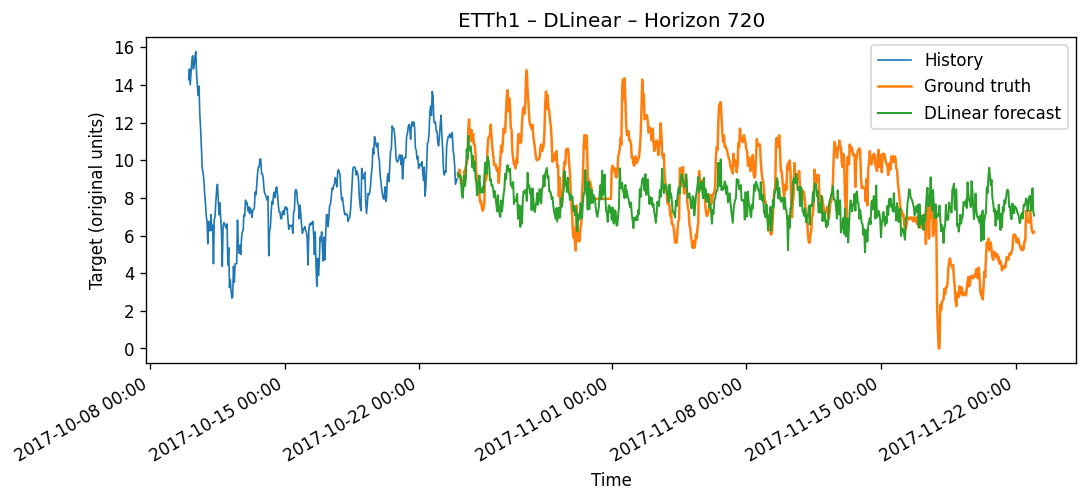

[ETTh1] DLinear – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.074262
MAE (scaled): 0.225962
DTW (scaled): 107.424228
TDI (scaled): 0.152970


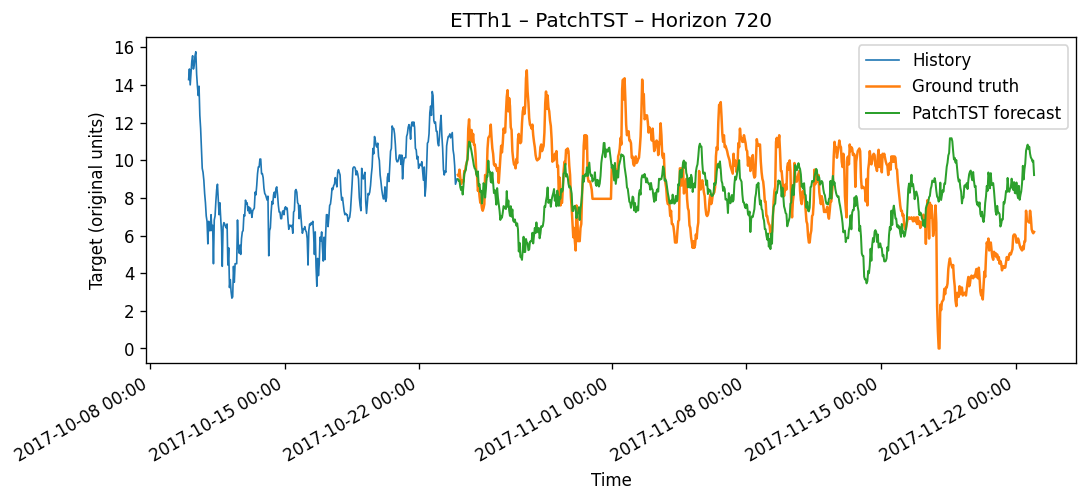

[ETTh1] PatchTST – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.116474
MAE (scaled): 0.276626
DTW (scaled): 104.613493
TDI (scaled): 0.144128


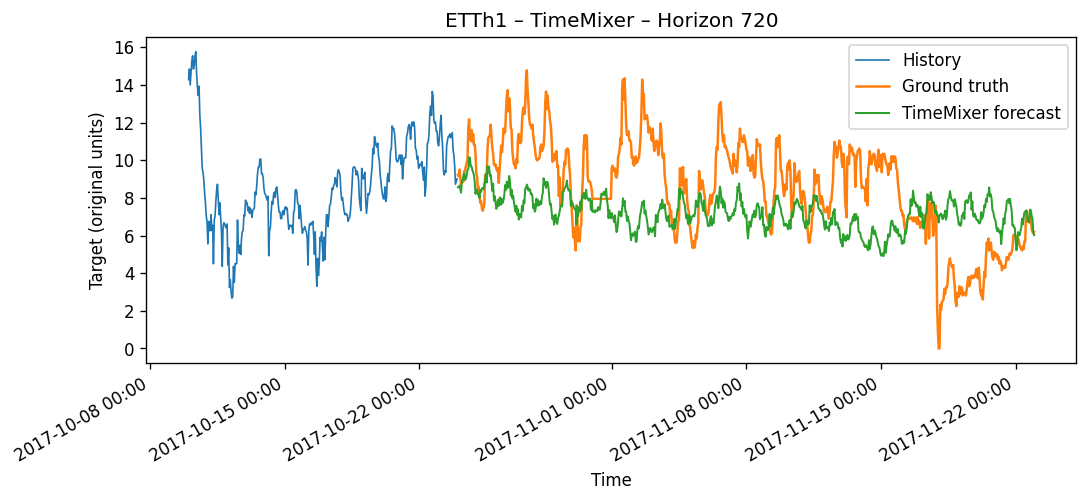

[ETTh1] TimeMixer – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.097803
MAE (scaled): 0.260833
DTW (scaled): 110.443467
TDI (scaled): 0.201325


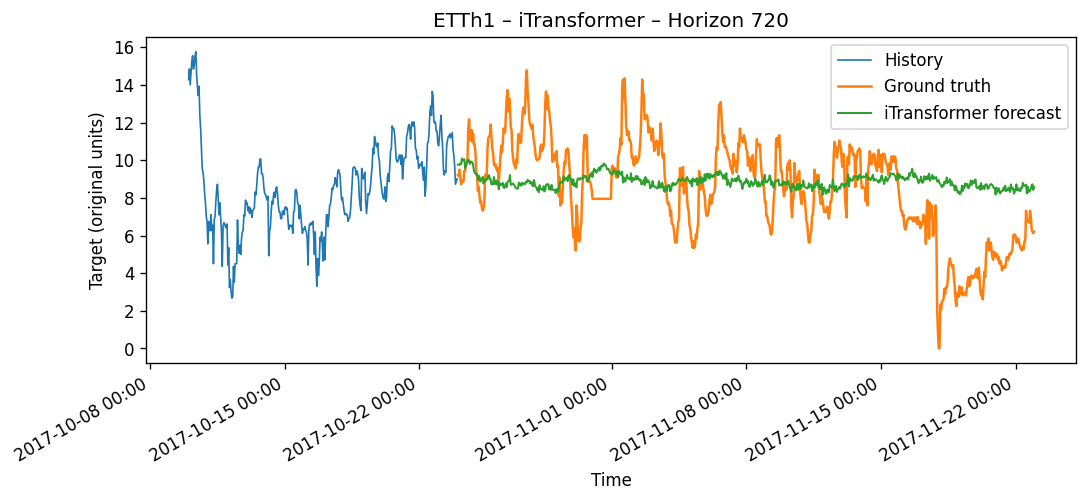

[ETTh1] iTransformer – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.079135
MAE (scaled): 0.227650
DTW (scaled): 137.766127
TDI (scaled): 0.056599

Dataset: ETTm1
[ETTm1] INFO: dataset length 69680 > LTSF total 57600. Using first 57600 points and ignoring extra tail.
Using columns for quantiles -> lower: 0.1, median: predictions, upper: 0.9


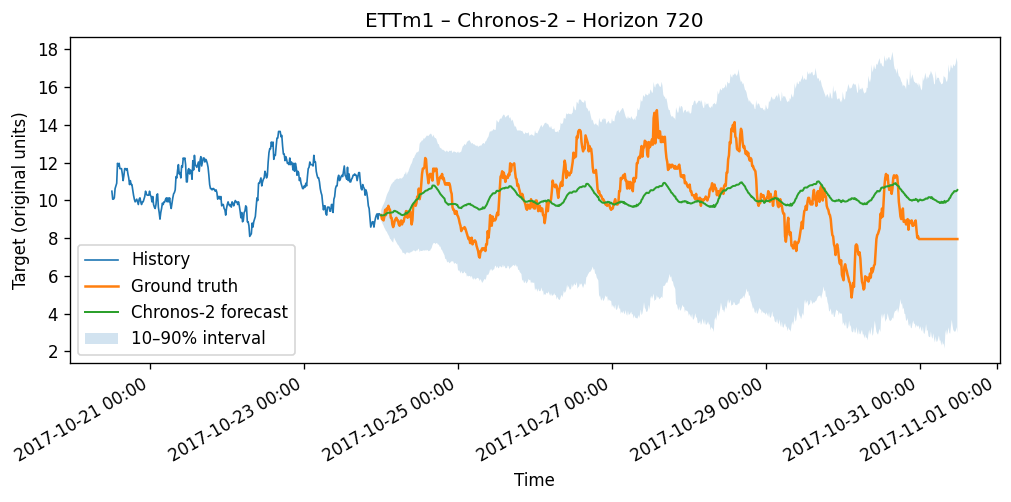

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


[ETTm1] Chronos-2 – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.034564
MAE (scaled): 0.145718
DTW (scaled): 88.605872
TDI (scaled): 0.078966


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train  │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler        │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ decomp        │ SeriesDecomp  │      0 │ train │     0 │
│ 4 │ linear_trend  │ Linear        │  242 K │ train │     0 │
│ 5 │ linear_season │ Linear        │  242 K │ train │     0 │
└───┴───────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 485 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 485 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

Output()

INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.rich_model_summary.RichModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.rich_model_summary.RichModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

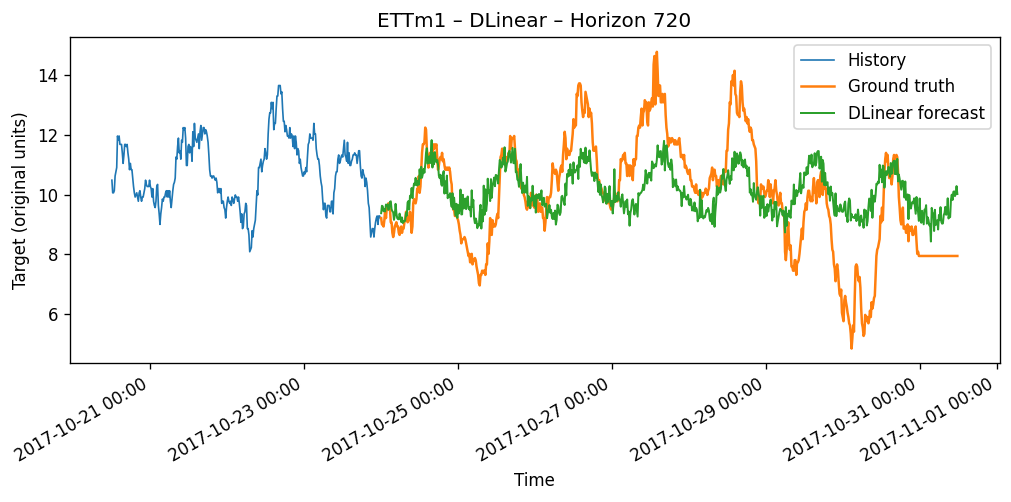

[ETTm1] DLinear – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.027206
MAE (scaled): 0.131652
DTW (scaled): 61.333560
TDI (scaled): 0.054788


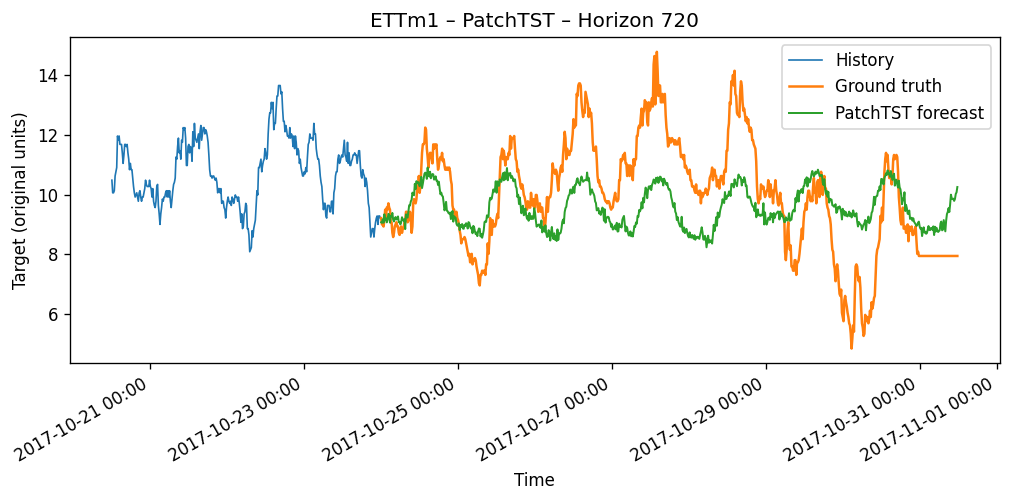

[ETTm1] PatchTST – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.034403
MAE (scaled): 0.153469
DTW (scaled): 89.465107
TDI (scaled): 0.206911


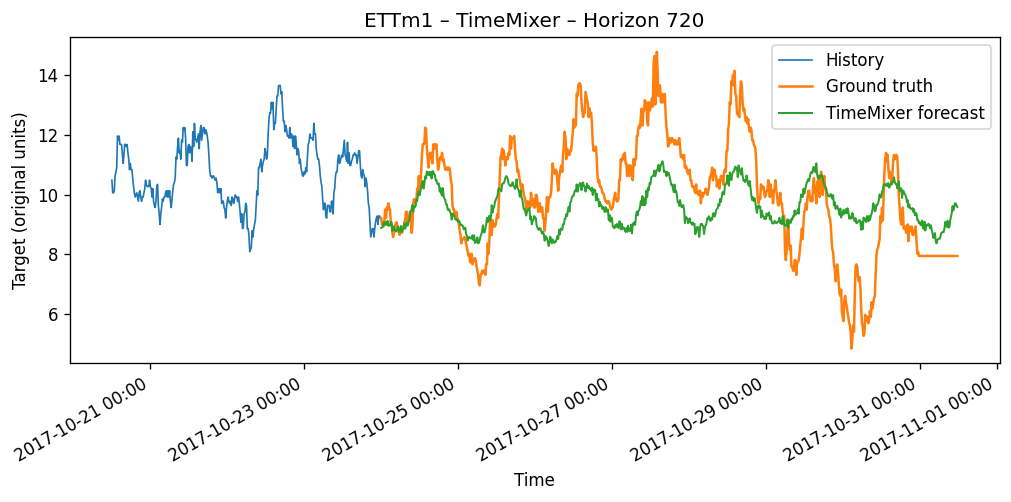

[ETTm1] TimeMixer – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.030638
MAE (scaled): 0.142953
DTW (scaled): 78.325586
TDI (scaled): 0.093937


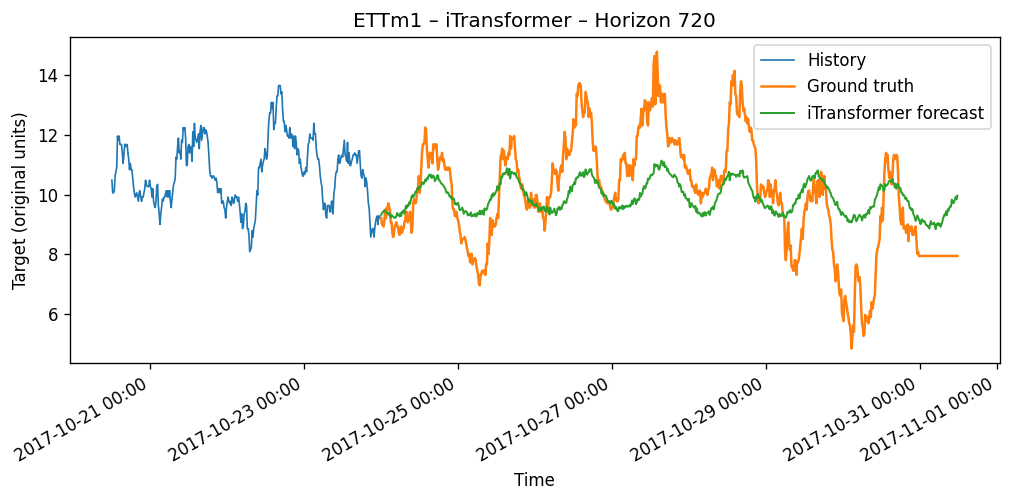

[ETTm1] iTransformer – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.027086
MAE (scaled): 0.131405
DTW (scaled): 71.843441
TDI (scaled): 0.040505

Dataset: ETTm2
[ETTm2] INFO: dataset length 69680 > LTSF total 57600. Using first 57600 points and ignoring extra tail.
Using columns for quantiles -> lower: 0.1, median: predictions, upper: 0.9


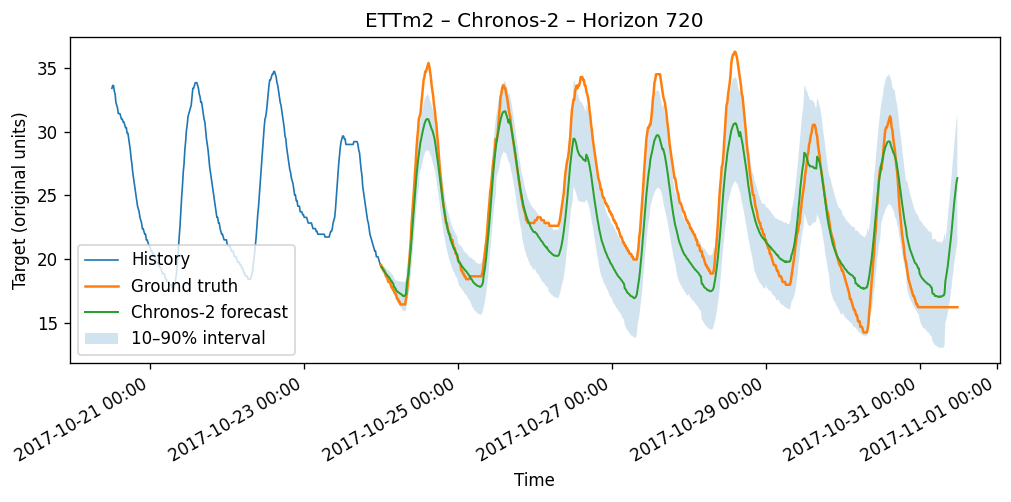

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


[ETTm2] Chronos-2 – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.053254
MAE (scaled): 0.183383
DTW (scaled): 69.943499
TDI (scaled): 0.010988


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train  │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler        │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ decomp        │ SeriesDecomp  │      0 │ train │     0 │
│ 4 │ linear_trend  │ Linear        │  242 K │ train │     0 │
│ 5 │ linear_season │ Linear        │  242 K │ train │     0 │
└───┴───────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 485 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 485 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

Output()

INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.rich_model_summary.RichModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.rich_model_summary.RichModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

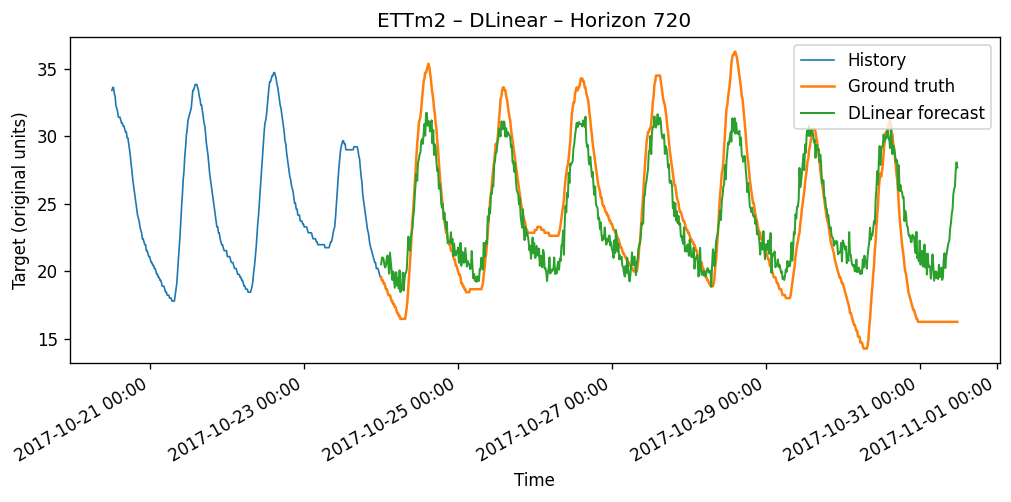

[ETTm2] DLinear – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.060156
MAE (scaled): 0.195555
DTW (scaled): 84.045553
TDI (scaled): 0.010485


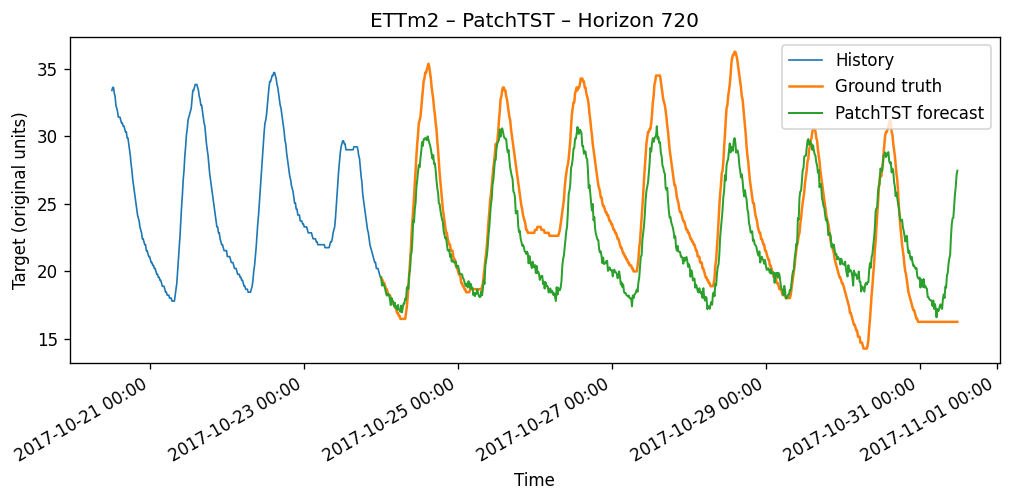

[ETTm2] PatchTST – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.071064
MAE (scaled): 0.218202
DTW (scaled): 106.468299
TDI (scaled): 0.070713


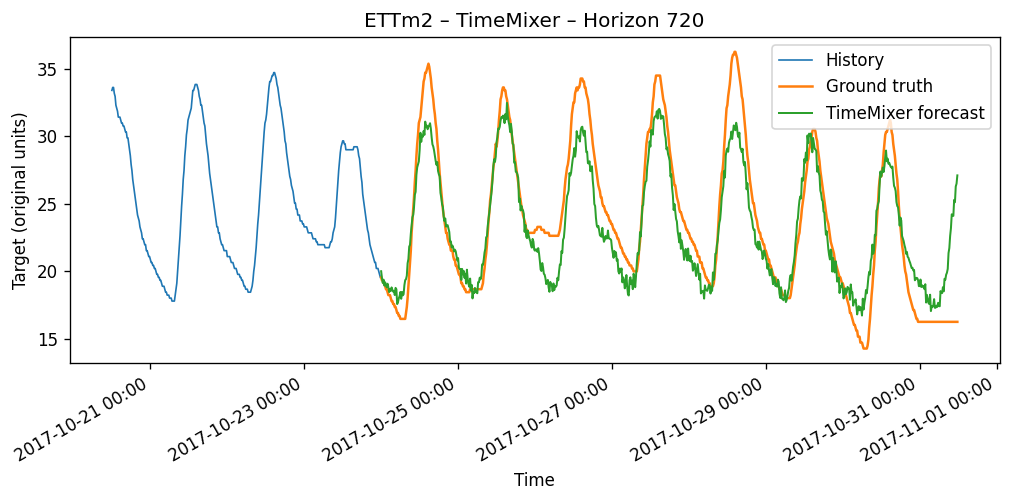

[ETTm2] TimeMixer – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.041803
MAE (scaled): 0.159356
DTW (scaled): 61.857387
TDI (scaled): 0.008321


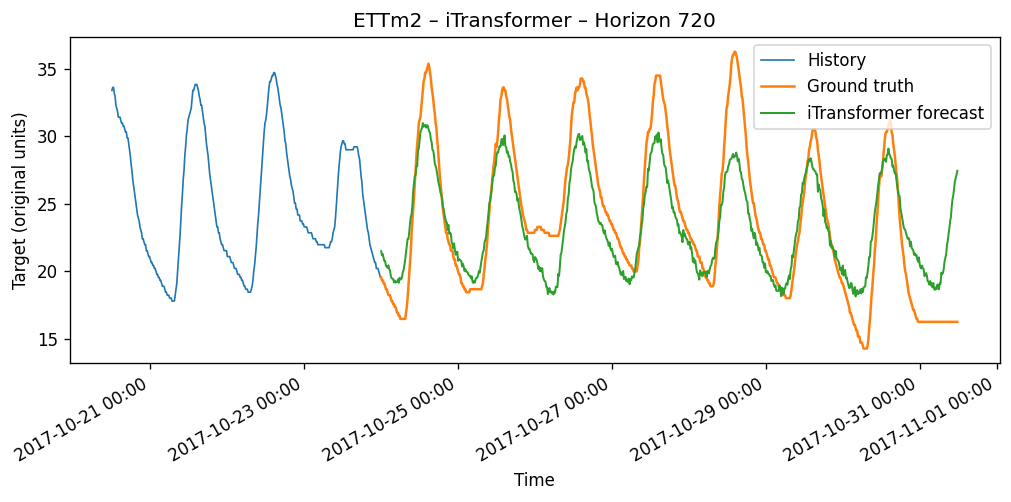

[ETTm2] iTransformer – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.066575
MAE (scaled): 0.209055
DTW (scaled): 87.755995
TDI (scaled): 0.010697

Dataset: Weather
[Weather] WARNING: irregular timestamps; using regular freq '10min'
[Weather] INFO: dataset length 52696 > LTSF total 52603. Using first 52603 points and ignoring extra tail.
Using columns for quantiles -> lower: 0.1, median: predictions, upper: 0.9


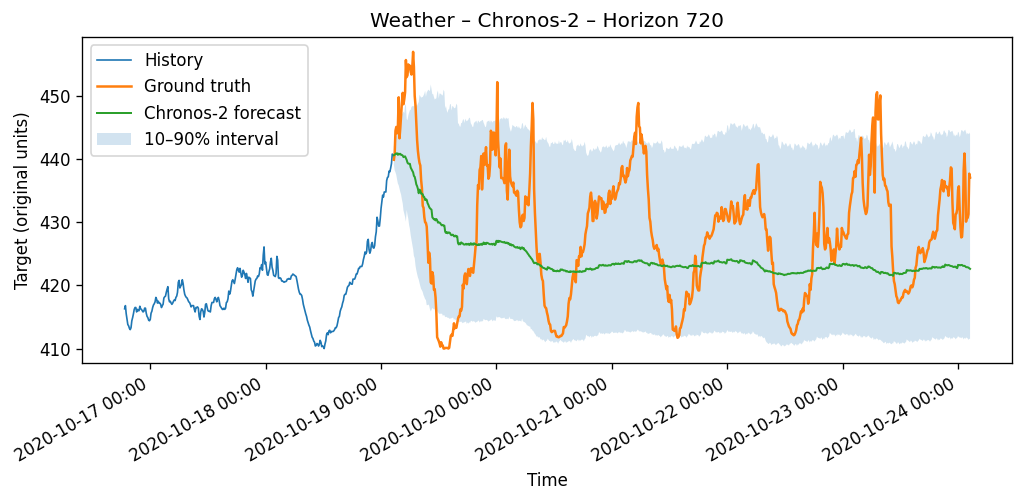

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


[Weather] Chronos-2 – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.000711
MAE (scaled): 0.022547
DTW (scaled): 15.139258
TDI (scaled): 0.137977


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train  │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler        │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ decomp        │ SeriesDecomp  │      0 │ train │     0 │
│ 4 │ linear_trend  │ Linear        │  242 K │ train │     0 │
│ 5 │ linear_season │ Linear        │  242 K │ train │     0 │
└───┴───────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 485 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 485 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

Output()

INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.rich_model_summary.RichModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.rich_model_summary.RichModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

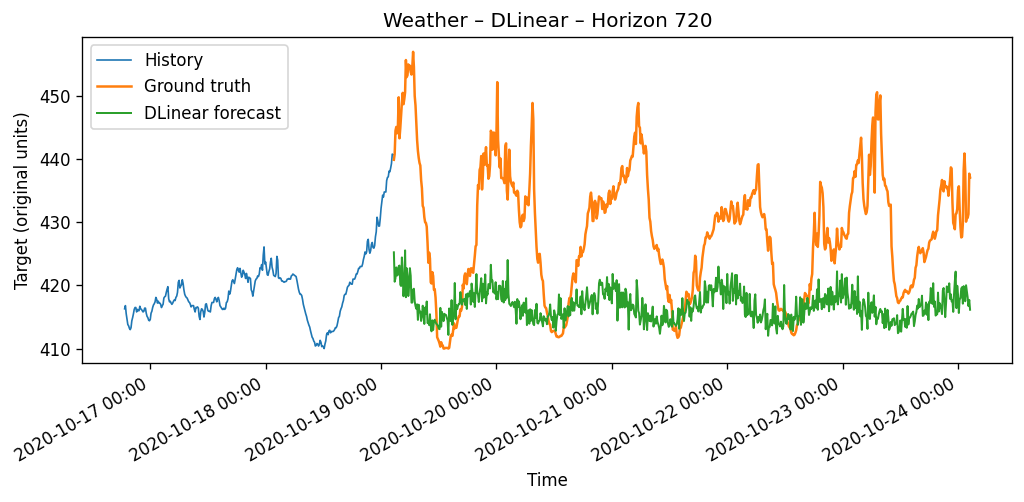

[Weather] DLinear – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.001533
MAE (scaled): 0.032258
DTW (scaled): 17.822407
TDI (scaled): 0.037033


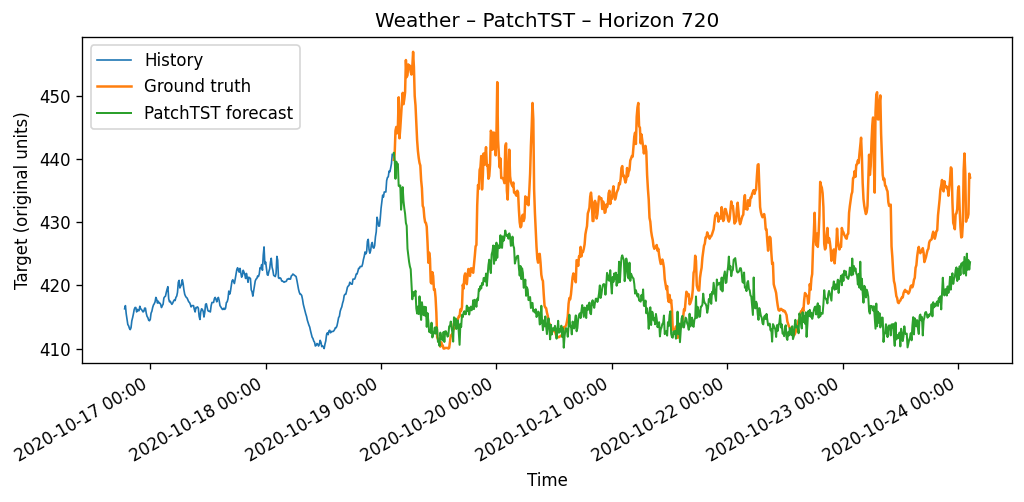

[Weather] PatchTST – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.001222
MAE (scaled): 0.028949
DTW (scaled): 12.984694
TDI (scaled): 0.066653


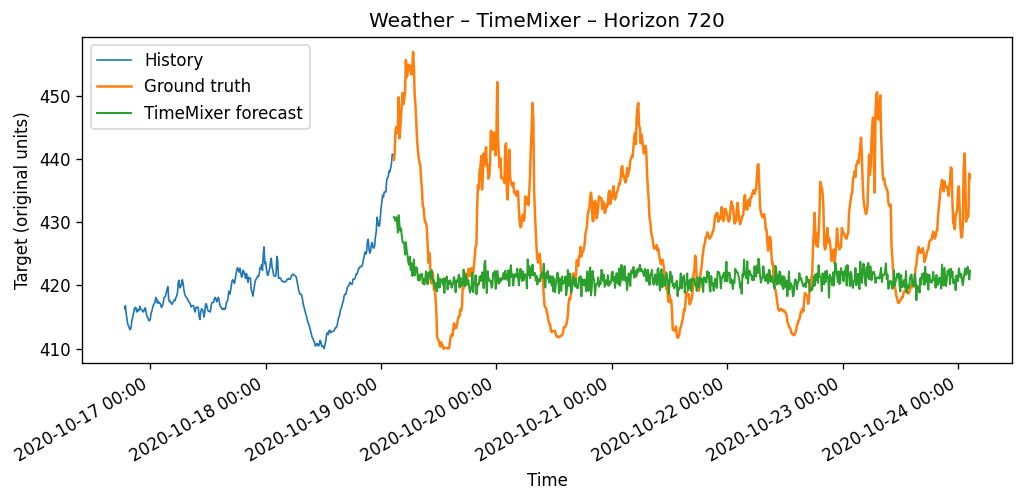

[Weather] TimeMixer – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.000982
MAE (scaled): 0.025898
DTW (scaled): 16.387781
TDI (scaled): 0.092788


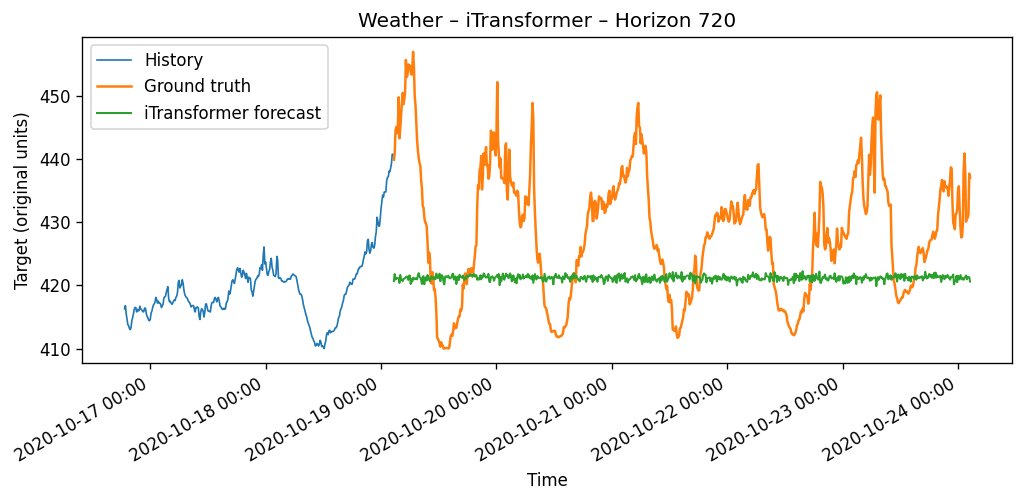

[Weather] iTransformer – single horizon (ALL METRICS SCALED)
MSE (scaled): 0.001074
MAE (scaled): 0.026921
DTW (scaled): 18.934525
TDI (scaled): 0.064990

Dataset: ESNet
[ESNet] n=69082, horizon_days=15, pred_len=4321, n_train=51808, n_val=12953, n_test=4321, test_start_idx=64761, test_start_ts=2025-02-03 06:25:01


/usr/local/lib/python3.12/dist-packages/chronos/chronos2/pipeline.py:601: UserWarning: We recommend keeping prediction length <= 1024. The quality of longer predictions may degrade since the model is not optimized for it. 
  warnings.warn(msg)


Using columns for quantiles -> lower: 0.1, median: predictions, upper: 0.9


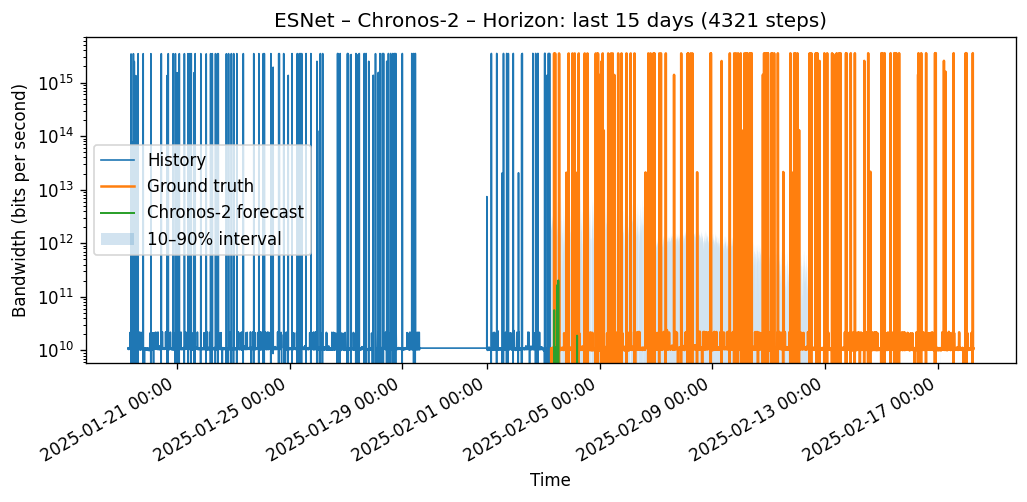

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1


[ESNet] Chronos-2 – single horizon (ALL METRICS SCALED)
MSE (scaled): 1.409463
MAE (scaled): 0.193827
DTW (scaled): 837.525415
TDI (scaled): 0.000364


INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train  │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler        │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ decomp        │ SeriesDecomp  │      0 │ train │     0 │
│ 4 │ linear_trend  │ Linear        │  1.5 M │ train │     0 │
│ 5 │ linear_season │ Linear        │  1.5 M │ train │     0 │
└───┴───────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 2.9 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.9 M                                                                                                
Total estimated model params size (MB): 11                                                                         
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

Output()

INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.rich_model_summary.RichModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.rich_model_summary.RichModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

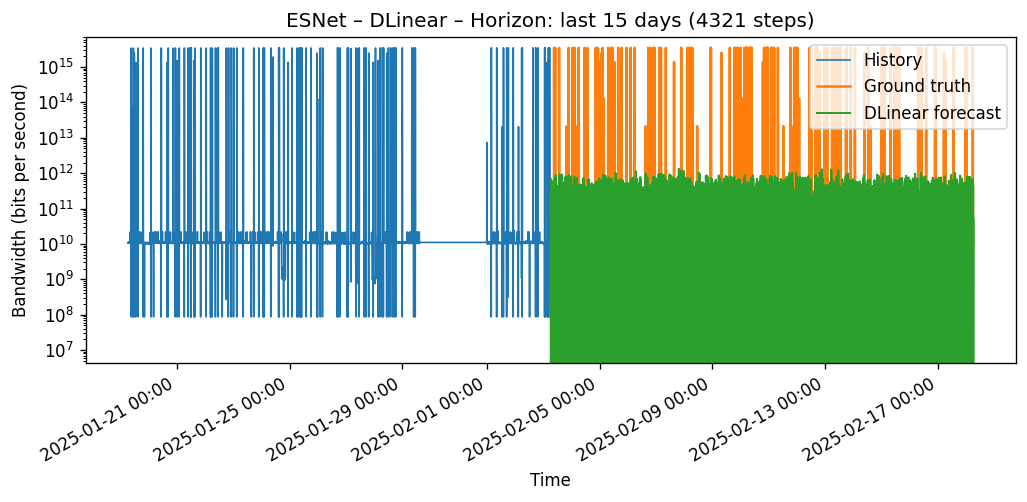

[ESNet] DLinear – single horizon (ALL METRICS SCALED)
MSE (scaled): 1.407201
MAE (scaled): 0.188722
DTW (scaled): 815.415552
TDI (scaled): 0.043592


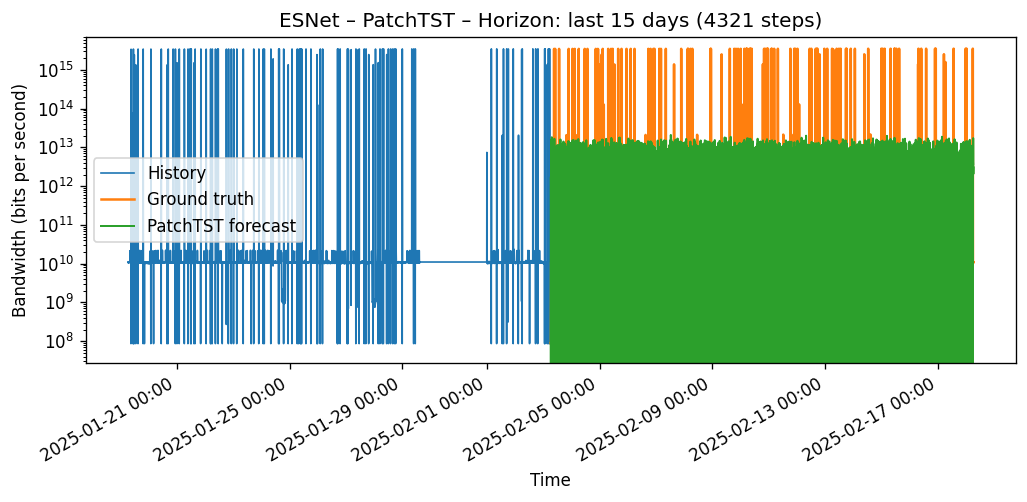

[ESNet] PatchTST – single horizon (ALL METRICS SCALED)
MSE (scaled): 1.404271
MAE (scaled): 0.199130
DTW (scaled): 857.144090
TDI (scaled): 0.021594


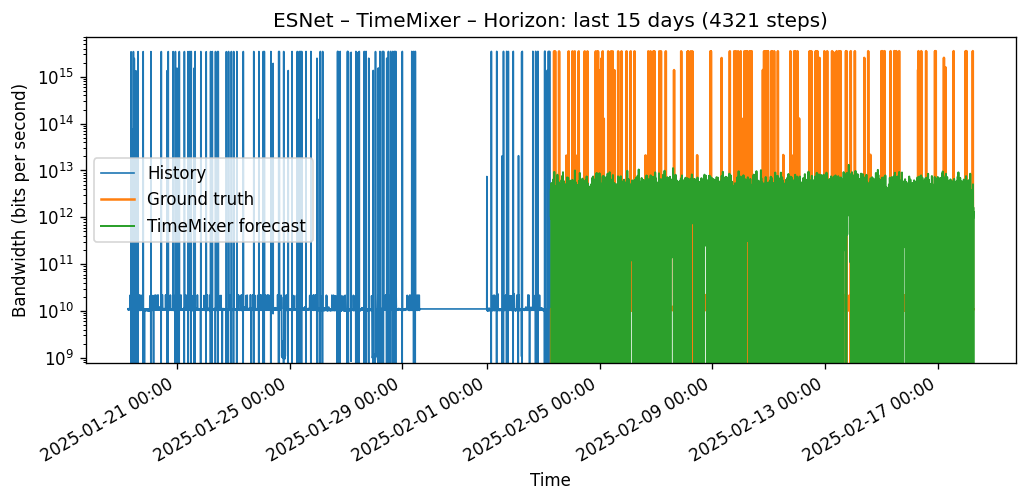

[ESNet] TimeMixer – single horizon (ALL METRICS SCALED)
MSE (scaled): 1.405384
MAE (scaled): 0.194284
DTW (scaled): 837.499411
TDI (scaled): 0.014525
Saved metrics CSV to: results/h720/metrics_h720.csv


,dataset,model,horizon_len,mse_scaled,mae_scaled,dtw_scaled,tdi_scaled,protocol,fig_path
0,ETTh1,Chronos-2,720,0.233049,0.373450,258.413805,0.043094,single_horizon_scaled,results/h720/ETTh1_Chronos-2_h720.png
1,ETTh1,DLinear,720,0.074262,0.225962,107.424228,0.152970,single_horizon_scaled,results/h720/ETTh1_DLinear_h720.png
2,ETTh1,PatchTST,720,0.116474,0.276626,104.613493,0.144128,single_horizon_scaled,results/h720/ETTh1_PatchTST_h720.png
3,ETTh1,TimeMixer,720,0.097803,0.260833,110.443467,0.201325,single_horizon_scaled,results/h720/ETTh1_TimeMixer_h720.png
4,ETTh1,iTransformer,720,0.079135,0.227650,137.766127,0.056599,single_horizon_scaled,results/h720/ETTh1_iTransformer_h720.png
5,ETTm1,Chronos-2,720,0.034564,0.145718,88.605872,0.078966,single_horizon_scaled,results/h720/ETTm1_Chronos-2_h720.png
6,ETTm1,DLinear,720,0.027206,0.131652,61.333560,0.054788,single_horizon_scaled,results/h720/ETTm1_DLinear_h720.png
7,ETTm1,PatchTST,720,0.034403,0.153469,89.465107,0.206911,single_horizon_scaled,results/h720/ETTm1_PatchTST_h720.png
8,ETTm1,TimeMixer,720,0.030638,0.142953,78.325586,0.093937,single_horizon_scaled,results/h720/ETTm1_TimeMixer_h720.png
9,ETTm1,iTransformer,720,0.027086,0.131405,71.843441,0.040505,single_horizon_scaled,results/h720/ETTm1_iTransformer_h720.png


In [21]:
PREDICTION_LENGTH = 720
all_results = []

RESULTS_SUBDIR = os.path.join(BASE_RESULTS_DIR, f"h{PREDICTION_LENGTH}")
os.makedirs(RESULTS_SUBDIR, exist_ok=True)
print("Saving results to:", RESULTS_SUBDIR)

for ds_name, path in DATASETS.items():
    print("\n" + "=" * 80)
    print(f"Dataset: {ds_name}")
    dataset = prepare_dataset(ds_name, path)

    # Chronos-2
    chr_pred_scaled, chr_lower_scaled, chr_upper_scaled = chronos_predict_scaled(
        dataset, pipeline
    )
    res = plot_and_metrics(
        dataset,
        "Chronos-2",
        chr_pred_scaled,
        lower_scaled=chr_lower_scaled,
        upper_scaled=chr_upper_scaled,
        results_dir=RESULTS_SUBDIR,
    )
    all_results.append(res)

    # NeuralForecast models
    nf_preds = nf_predict_scaled(dataset)
    for model_name, pred_scaled in nf_preds.items():
        res = plot_and_metrics(
            dataset,
            model_name,
            pred_scaled,
            results_dir=RESULTS_SUBDIR,
        )
        all_results.append(res)

metrics_df = pd.DataFrame(all_results)

csv_path = os.path.join(RESULTS_SUBDIR, f"metrics_h{PREDICTION_LENGTH}.csv")
metrics_df.to_csv(csv_path, index=False)
print("Saved metrics CSV to:", csv_path)

metrics_df

In [22]:
import shutil
import os

directory_to_zip = 'results'
output_zip_name = 'results.zip'

shutil.make_archive(output_zip_name.split('.')[0], 'zip', directory_to_zip)

'/content/results.zip'